In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Load data
tsne_df = pd.read_csv("figure_data/fig2A_pretraining_data_mfp_tsne.csv")

# Style setup
sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.linewidth": 0.8,
    "axes.edgecolor": "0.2",
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)

# make colormap
palette = sns.color_palette("Set2", desat=0.8)
colormap = palette.as_hex()[0:3]
colormap = ['#6abcdb', '#edbb64', '#dc8356']

# make colors brighter add brightness function
def brighten_color(color, factor=0):
    color = mpl.colors.to_rgb(color)
    brightened = tuple(min(1, c + factor) for c in color)
    return brightened

for i in range(len(colormap)):
    colormap[i] = brighten_color(colormap[i], factor=-0.05)

# desat colors
def desat_color(color, factor=0.5):
    color = mpl.colors.to_rgb(color)
    desaturated = tuple(c * factor + (1 - factor) * 0.5 for c in color)
    return desaturated

for i in range(len(colormap)):
    colormap[i] = desat_color(colormap[i], factor=1.1)

# make more vibrant
def saturate_color(color, factor=1.2):
    color = mpl.colors.to_rgb(color)
    gray = sum(color) / 3
    saturated = tuple(
        max(0, min(1, gray + (c - gray) * factor)) for c in color
    )
    return saturated

for i in range(len(colormap)):
    colormap[i] = saturate_color(colormap[i], factor=1.1)

# print colormap as hex
for i in range(len(colormap)):
    colormap[i] = mpl.colors.to_hex(colormap[i])
# print(colormap)

scatter = ax.scatter(
    tsne_df["t-SNE1"],
    tsne_df["t-SNE2"],
    c=tsne_df["source"].map({k: v for v, k in enumerate(tsne_df["source"].unique())}),
    cmap=mpl.colors.ListedColormap(colormap),
    s=3,
    alpha=0.5,
    edgecolors="none"
)

# build legend with color patches
handles = [
    mpl.patches.Patch(color=colormap[i], label=label)
    for i, label in enumerate(tsne_df["source"].unique())
]
ax.legend(
    handles=handles,
    title=None,
    loc="upper right",
    frameon=False,
    fontsize=9,
    handlelength=1.2,
    handletextpad=0.4,
)

ax.set_xlabel("t-SNE 1", fontsize=12, labelpad=6)
ax.set_ylabel("t-SNE 2", fontsize=12, labelpad=6)
ax.set_xticks([])
ax.set_yticks([])
sns.despine(ax=ax, left=True, bottom=True)

plt.savefig("figures/fig2A_pretraining_data.svg", bbox_inches="tight", dpi=300)
plt.savefig("figures/fig2A_pretraining_data.pdf", bbox_inches="tight", dpi=300)

: 

In [6]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib as mpl

# # Load data
# tsne_df = pd.read_csv("figure_data/fig2A_pretraining_data_mfp_tsne.csv")

# # Style setup
# sns.set_theme(style="white", context="talk")
# plt.rcParams.update({
#     "font.family": "sans-serif",
#     "font.sans-serif": ["DejaVu Sans"],
#     "axes.linewidth": 0.8,
#     "axes.edgecolor": "0.2",
#     "xtick.direction": "out",
#     "ytick.direction": "out",
# })

# # Plot
# fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)

# # make colormap
# palette = sns.color_palette("Set2", desat=0.8)
# colormap = palette.as_hex()[0:3]
# colormap = ['#6abcdb', '#edbb64', '#dc8356']

# # make colors brighter add brightness function
# def brighten_color(color, factor=0):
#     color = mpl.colors.to_rgb(color)
#     brightened = tuple(min(1, c + factor) for c in color)
#     return brightened

# for i in range(len(colormap)):
#     colormap[i] = brighten_color(colormap[i], factor=-0.05)

# # desat colors
# def desat_color(color, factor=0.5):
#     color = mpl.colors.to_rgb(color)
#     desaturated = tuple(c * factor + (1 - factor) * 0.5 for c in color)
#     return desaturated

# for i in range(len(colormap)):
#     colormap[i] = desat_color(colormap[i], factor=1.1)

# # make more vibrant
# def saturate_color(color, factor=1.2):
#     color = mpl.colors.to_rgb(color)
#     gray = sum(color) / 3
#     saturated = tuple(
#         max(0, min(1, gray + (c - gray) * factor)) for c in color
#     )
#     return saturated

# for i in range(len(colormap)):
#     colormap[i] = saturate_color(colormap[i], factor=1.1)

# # print colormap as hex
# for i in range(len(colormap)):
#     colormap[i] = mpl.colors.to_hex(colormap[i])
# # print(colormap)

# # generate embeddings using MLM model and then calculate t-SNE and plot
# from sklearn.manifold import TSNE
# from transformers import AutoTokenizer, AutoModel
# import torch
# from tqdm import tqdm
# import numpy as np


# # load model from huggingface
# def load_model(model_name="aaronfeller/PeptideMLM_lg"):
#     tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
#     model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
#     return model, tokenizer

# model, tokenizer = load_model()

# def generate_embeddings(model, tokenizer, sequences, batch_size=64):
#     embeddings = []
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model.to(device)
#     for i in tqdm(range(0, len(sequences), batch_size)):
#         batch_seq = sequences[i:i+batch_size]
#         inputs = tokenizer(batch_seq, return_tensors="pt", padding=True, truncation=True).to(device)
#         with torch.no_grad():
#             outputs = model(**inputs)
#         # mean pool the token embeddings to get a single embedding per sequence
#         batch_embeddings = outputs['mean_pool'].cpu().numpy()
#         embeddings.extend(batch_embeddings)
#     return np.array(embeddings)

# # generate embeddings
# sequences = tsne_df["smiles"].tolist()
# embeddings = generate_embeddings(model, tokenizer, sequences, batch_size=64)

# calculate t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=123)
tsne_results = tsne.fit_transform(embeddings)
tsne_df["ML_t-SNE1"] = tsne_results[:, 0]
tsne_df["ML_t-SNE2"] = tsne_results[:, 1]


scatter = ax.scatter(
    tsne_df["ML_t-SNE1"],
    tsne_df["ML_t-SNE2"],
    c=tsne_df["source"].map({k: v for v, k in enumerate(tsne_df["source"].unique())}),
    cmap=mpl.colors.ListedColormap(colormap),
    s=3,
    alpha=0.5,
    edgecolors="none"
)

# build legend with color patches
handles = [
    mpl.patches.Patch(color=colormap[i], label=label)
    for i, label in enumerate(tsne_df["source"].unique())
]
ax.legend(
    handles=handles,
    title=None,
    loc="upper right",
    frameon=False,
    fontsize=9,
    handlelength=1.2,
    handletextpad=0.4,
)

ax.set_xlabel("t-SNE 1", fontsize=12, labelpad=6)
ax.set_ylabel("t-SNE 2", fontsize=12, labelpad=6)
ax.set_xticks([])
ax.set_yticks([])
sns.despine(ax=ax, left=True, bottom=True)

plt.show()

# plt.savefig("figures/fig2A_pretraining_data.svg", bbox_inches="tight", dpi=300)
# plt.savefig("figures/fig2A_pretraining_data.pdf", bbox_inches="tight", dpi=300)

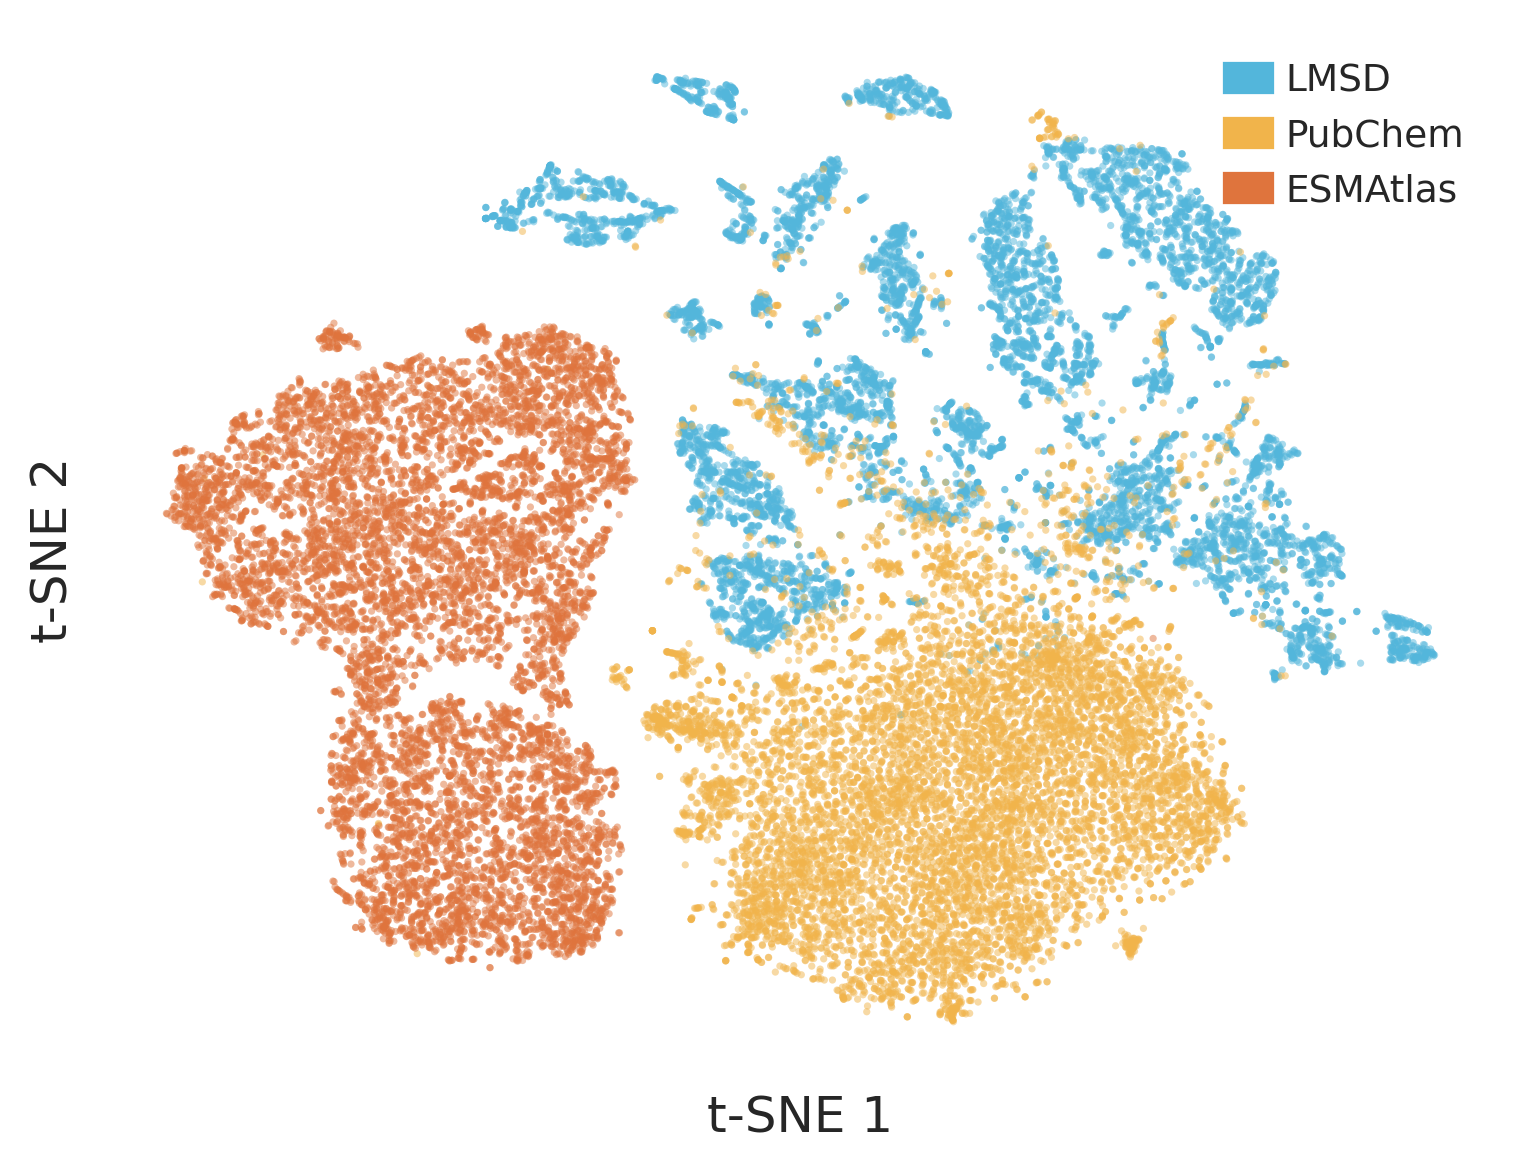

In [10]:

# Style setup
sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.linewidth": 0.8,
    "axes.edgecolor": "0.2",
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)

# make colormap
palette = sns.color_palette("Set2", desat=0.8)
colormap = palette.as_hex()[0:3]
colormap = ['#6abcdb', '#edbb64', '#dc8356']

# make colors brighter add brightness function
def brighten_color(color, factor=0):
    color = mpl.colors.to_rgb(color)
    brightened = tuple(min(1, c + factor) for c in color)
    return brightened

for i in range(len(colormap)):
    colormap[i] = brighten_color(colormap[i], factor=-0.05)

# desat colors
def desat_color(color, factor=0.5):
    color = mpl.colors.to_rgb(color)
    desaturated = tuple(c * factor + (1 - factor) * 0.5 for c in color)
    return desaturated

for i in range(len(colormap)):
    colormap[i] = desat_color(colormap[i], factor=1.1)

# make more vibrant
def saturate_color(color, factor=1.2):
    color = mpl.colors.to_rgb(color)
    gray = sum(color) / 3
    saturated = tuple(
        max(0, min(1, gray + (c - gray) * factor)) for c in color
    )
    return saturated

for i in range(len(colormap)):
    colormap[i] = saturate_color(colormap[i], factor=1.1)

# print colormap as hex
for i in range(len(colormap)):
    colormap[i] = mpl.colors.to_hex(colormap[i])
# print(colormap)

# # generate embeddings using MLM model and then calculate t-SNE and plot
# from sklearn.manifold import TSNE
# from transformers import AutoTokenizer, AutoModel
# import torch
# from tqdm import tqdm
# import numpy as np


# # load model from huggingface
# def load_model(model_name="aaronfeller/PeptideMLM_lg"):
#     tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
#     model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
#     return model, tokenizer

# model, tokenizer = load_model()

# def generate_embeddings(model, tokenizer, sequences, batch_size=64):
#     embeddings = []
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model.to(device)
#     for i in tqdm(range(0, len(sequences), batch_size)):
#         batch_seq = sequences[i:i+batch_size]
#         inputs = tokenizer(batch_seq, return_tensors="pt", padding=True, truncation=True).to(device)
#         with torch.no_grad():
#             outputs = model(**inputs)
#         # mean pool the token embeddings to get a single embedding per sequence
#         batch_embeddings = outputs['mean_pool'].cpu().numpy()
#         embeddings.extend(batch_embeddings)
#     return np.array(embeddings)

# # generate embeddings
# sequences = tsne_df["smiles"].tolist()
# embeddings = generate_embeddings(model, tokenizer, sequences, batch_size=64)

# # calculate t-SNE
# tsne = TSNE(n_components=2, perplexity=30, random_state=123)
# tsne_results = tsne.fit_transform(embeddings)
# tsne_df["ML_t-SNE1"] = tsne_results[:, 0]
# tsne_df["ML_t-SNE2"] = tsne_results[:, 1]


scatter = ax.scatter(
    tsne_df["ML_t-SNE1"],
    tsne_df["ML_t-SNE2"],
    c=tsne_df["source"].map({k: v for v, k in enumerate(tsne_df["source"].unique())}),
    cmap=mpl.colors.ListedColormap(colormap),
    s=3,
    alpha=0.5,
    edgecolors="none"
)

# build legend with color patches
handles = [
    mpl.patches.Patch(color=colormap[i], label=label)
    for i, label in enumerate(tsne_df["source"].unique())
]
ax.legend(
    handles=handles,
    title=None,
    loc="upper right",
    frameon=False,
    fontsize=9,
    handlelength=1.2,
    handletextpad=0.4,
)

ax.set_xlabel("t-SNE 1", fontsize=12, labelpad=6)
ax.set_ylabel("t-SNE 2", fontsize=12, labelpad=6)
ax.set_xticks([])
ax.set_yticks([])
sns.despine(ax=ax, left=True, bottom=True)

plt.show()

# plt.savefig("figures/fig2A_pretraining_data.svg", bbox_inches="tight", dpi=300)
# plt.savefig("figures/fig2A_pretraining_data.pdf", bbox_inches="tight", dpi=300)

In [11]:
# save tsne_df to csv
tsne_df.to_csv("figure_data/fig2A_pretraining_data_mlm_tsne.csv", index=False)

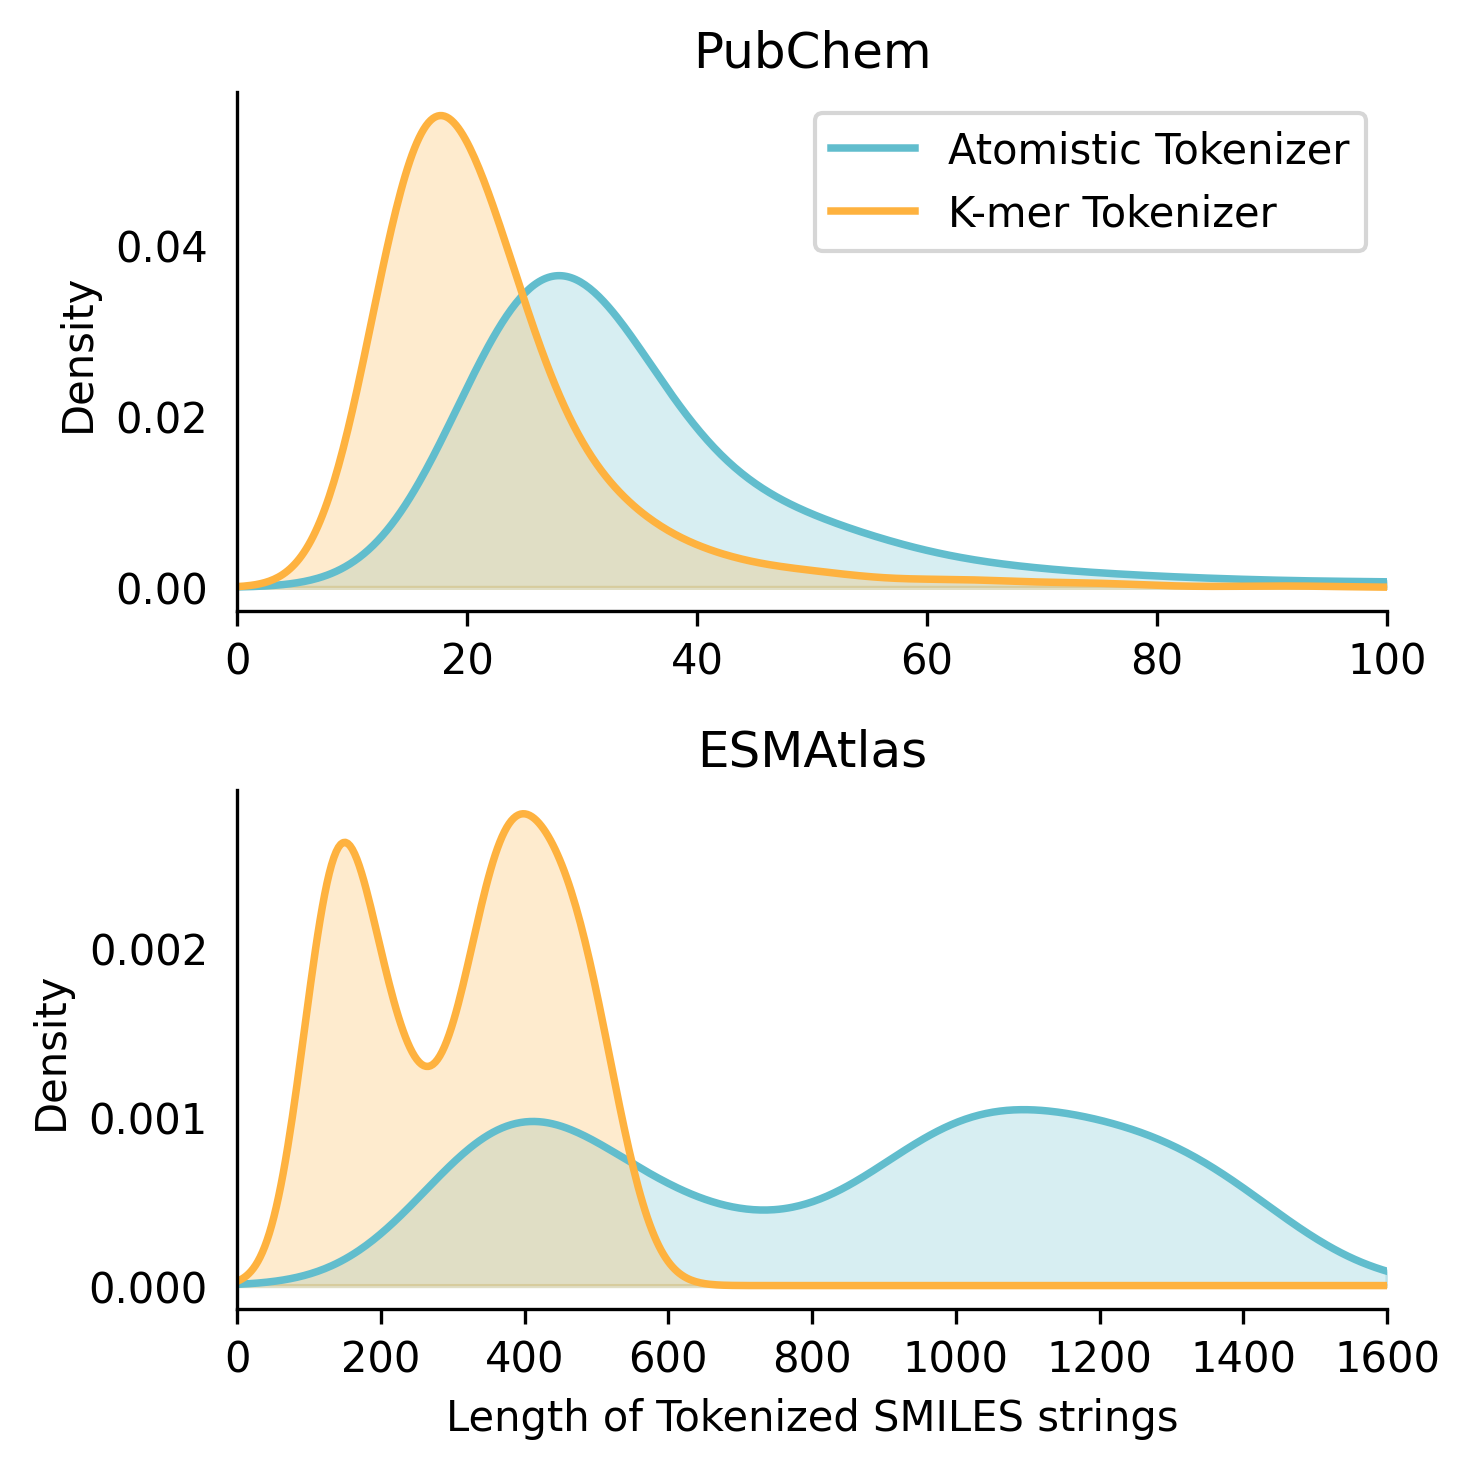

ESMAtlas:
  Avg Atomistic: 860.39
  Avg K-mer: 312.24
  Compression Ratio (K/A): 0.36
----------------------------------------
PubChem:
  Avg Atomistic: 36.08
  Avg K-mer: 22.43
  Compression Ratio (K/A): 0.62
----------------------------------------


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

# Reset params
plt.rcParams.update(plt.rcParamsDefault)

# --- Load datasets ---
ea_lengths_df = pd.read_csv('figure_data/fig2B_token_lengths_ESM_Atlas.csv')
pc_lengths_df = pd.read_csv('figure_data/fig2B_token_lengths_PubChem.csv')

# --- Extract columns ---
ea_a_lengths = ea_lengths_df['Atomistic_Length'].dropna().tolist()
ea_k_lengths = ea_lengths_df['Kmer_Length'].dropna().tolist()

pc_a_lengths = pc_lengths_df['Atomistic_Length'].dropna().tolist()
pc_k_lengths = pc_lengths_df['Kmer_Length'].dropna().tolist()

# --- Define colors ---
colors = {
    "kmer": "#feb23f",   
    "atom": "#61bdcd" # muted blue # "#C791D4",
}

# --- Create vertically stacked subplots ---
fig, axes = plt.subplots(2, 1, figsize=(5, 5), sharex=False, dpi=300)

for ax in axes:
    ax.yaxis.set_ticks_position('none')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- Helper function for KDE ---
def plot_kde(ax, data, color, label, xlim):
    data = np.array(data)
    kde = gaussian_kde(data, bw_method=0.3)
    xs = np.linspace(0, xlim, 500)
    ax.plot(xs, kde(xs), color=color, lw=1.8, label=label)
    ax.fill_between(xs, kde(xs), color=color, alpha=0.25)

# --- PubChem plot ---
plot_kde(axes[0], pc_a_lengths, colors["atom"], "Atomistic Tokenizer", 100)
plot_kde(axes[0], pc_k_lengths, colors["kmer"], "K-mer Tokenizer", 100)
axes[0].set_xlim(0, 100)
axes[0].legend()
axes[0].set_ylabel('Density')
axes[0].set_title('PubChem')

# --- ESMAtlas plot ---
plot_kde(axes[1], ea_a_lengths, colors["atom"], "Atomistic Tokenizer", 1600)
plot_kde(axes[1], ea_k_lengths, colors["kmer"], "K-mer Tokenizer", 1600)
axes[1].set_xlim(0, 1600)
axes[1].set_ylabel('Density')
axes[1].set_xlabel('Length of Tokenized SMILES strings')
axes[1].set_title('ESMAtlas')

plt.tight_layout()

# plt.savefig("figures/fig2BC_pretraining_data.svg", bbox_inches="tight", dpi=300)
# plt.savefig("figures/fig2BC_pretraining_data.pdf", bbox_inches="tight", dpi=300)
plt.show()

# --- Compute averages & compression ratios ---
def summarize(name, a_lengths, k_lengths):
    avg_a = sum(a_lengths) / len(a_lengths) if a_lengths else 0
    avg_k = sum(k_lengths) / len(k_lengths) if k_lengths else 0
    ratio = avg_k / avg_a if avg_a else float('inf')
    print(f"{name}:")
    print(f"  Avg Atomistic: {avg_a:.2f}")
    print(f"  Avg K-mer: {avg_k:.2f}")
    print(f"  Compression Ratio (K/A): {ratio:.2f}")
    print("-" * 40)

summarize("ESMAtlas", ea_a_lengths, ea_k_lengths)
summarize("PubChem", pc_a_lengths, pc_k_lengths)

In [17]:
from pathlib import Path
import pandas as pd

FIGURE_DIR = Path.cwd()
REPO_ROOT = FIGURE_DIR.parent

MODEL_LABELS = {
    "small": "32M",
    "base": "114M",
    "large": "337M",
}

TRAINING_LABELS = {
    "mlm": "MLM",
    "hybrid": "MLM-MTR",
    "mtr": "MTR",
}

PRECOMPUTED_TRAINING_MAP = {
    "MLM_only": "MLM",
    "mlm_only": "MLM",
    "MLM-MTR": "MLM-MTR",
    "hybrid": "MLM-MTR",
    "Hybrid": "MLM-MTR",
    "MTR_only": "MTR",
    "mtr_only": "MTR",
}


def parse_model_metadata(model_name: str) -> tuple[str, str]:
    model_slug = model_name.split("/")[-1].lower().replace("_", "-")
    size_key = next(size for size in MODEL_LABELS if f"-{size}" in model_slug)
    training_key = next(training for training in TRAINING_LABELS if f"-{training}-" in model_slug)
    return MODEL_LABELS[size_key], TRAINING_LABELS[training_key]


def summarize_r2(records_df: pd.DataFrame) -> pd.DataFrame:
    if records_df.empty:
        return pd.DataFrame(columns=["Model", "Training_method", "R2", "R2_std", "n_seeds"])

    summary_df = (
        records_df.groupby(["Model", "Training_method"], as_index=False)
        .agg(
            R2=("R2", "mean"),
            R2_std=("R2", "std"),
            n_seeds=("R2", "size"),
        )
    )
    summary_df["R2_std"] = summary_df["R2_std"].fillna(0.0)
    return summary_df


def load_r2_from_metrics_dir(metrics_root: Path) -> pd.DataFrame:
    records = []
    for metrics_path in sorted(metrics_root.glob("*/seed_*/metrics.csv")):
        metrics_df = pd.read_csv(metrics_path)
        r2_series = metrics_df.loc[metrics_df["metric_name"] == "r2", "metric_value"]
        if r2_series.empty:
            continue

        model_name = metrics_path.parent.parent.name
        model_label, training_label = parse_model_metadata(model_name)
        records.append({
            "Model": model_label,
            "Training_method": training_label,
            "R2": float(r2_series.iloc[0]),
        })

    return summarize_r2(pd.DataFrame(records))


def load_baseline_r2(metrics_root: Path) -> float:
    r2_values = []
    for metrics_path in sorted(metrics_root.glob("seed_*/metrics.csv")):
        metrics_df = pd.read_csv(metrics_path)
        r2_series = metrics_df.loc[metrics_df["metric_name"] == "r2", "metric_value"]
        if not r2_series.empty:
            r2_values.append(float(r2_series.iloc[0]))
    return float(pd.Series(r2_values).mean())


def load_precomputed_finetuning(summary_csv: Path) -> pd.DataFrame:
    summary_df = pd.read_csv(summary_csv)
    summary_df = summary_df.copy()
    summary_df["Model"] = summary_df["model_size"].str.lower().map(MODEL_LABELS)
    summary_df["Training_method"] = summary_df["model_type"].map(PRECOMPUTED_TRAINING_MAP)
    summary_df = summary_df.dropna(subset=["Model", "Training_method"])

    # Aggregate in case multiple rows map to the same model/training bucket.
    summary_df = (
        summary_df.groupby(["Model", "Training_method"], as_index=False)
        .agg(
            R2=("mean_r2", "mean"),
            n_seeds=("run_count", "sum"),
        )
    )
    summary_df["R2_std"] = 0.0
    return summary_df


transfer_df = load_r2_from_metrics_dir(
    REPO_ROOT / "tmp" / "xgboost_full_rerun_20260526_121412" / "cycpeptmpdb_perm" / "xgboost_transformer"
    )

# Use the new precomputed finetuning summary for the right-side plot in Figure 3E.
finetune_df = load_precomputed_finetuning(
    FIGURE_DIR / "figure_data" / "fig3E_finetuning.csv"
    )
full_finetune_seed101_df = finetune_df.copy()

morgan_r2 = load_baseline_r2(
    REPO_ROOT / "tmp" / "xgboost_full_rerun_20260525_230031" / "cycpeptmpdb_perm" / "xgboost_morgan" / "xgboost-morgan"
    )
rdkit_r2 = load_baseline_r2(
    REPO_ROOT / "tmp" / "xgboost_full_rerun_20260525_230031" / "cycpeptmpdb_perm" / "xgboost_rdkit" / "xgboost-rdkit"
    )

model_order = ["32M", "114M", "337M"]
train_order = ["MLM", "MLM-MTR", "MTR"]

transfer_df["Model"] = pd.Categorical(transfer_df["Model"], categories=model_order, ordered=True)
transfer_df["Training_method"] = pd.Categorical(transfer_df["Training_method"], categories=train_order, ordered=True)
transfer_df = transfer_df.sort_values(["Model", "Training_method"]).reset_index(drop=True)

finetune_df["Model"] = pd.Categorical(finetune_df["Model"], categories=model_order, ordered=True)
finetune_df["Training_method"] = pd.Categorical(finetune_df["Training_method"], categories=train_order, ordered=True)
finetune_df = finetune_df.sort_values(["Model", "Training_method"]).reset_index(drop=True)

full_finetune_seed101_df["Model"] = pd.Categorical(
    full_finetune_seed101_df["Model"],
    categories=model_order,
    ordered=True,
    )
full_finetune_seed101_df["Training_method"] = pd.Categorical(
    full_finetune_seed101_df["Training_method"],
    categories=train_order,
    ordered=True,
    )
full_finetune_seed101_df = full_finetune_seed101_df.sort_values(
    ["Model", "Training_method"]
    ).reset_index(drop=True)

print("=== Transfer Learning Summary ===")
display(transfer_df)
print("=== Finetuning Summary (Precomputed) ===")
display(full_finetune_seed101_df)
print(f"MorganFP mean R²: {morgan_r2:.3f}")
print(f"RDKit99 mean R²: {rdkit_r2:.3f}")
print("Finetuning summary is now loaded from figure_data/fig3E_finetuning.csv.")

=== Transfer Learning Summary ===


,Model,Training_method,R2,R2_std,n_seeds
0,32M,MLM,0.139533,0.010741,3
1,32M,MLM-MTR,0.141277,0.009310,3
2,32M,MTR,0.197692,0.005763,3
3,114M,MLM,0.106448,0.010561,3
4,114M,MLM-MTR,0.168109,0.015826,3
5,114M,MTR,0.228226,0.007291,3
6,337M,MLM,0.120421,0.009903,3
7,337M,MLM-MTR,0.162939,0.006756,3
8,337M,MTR,0.240662,0.008271,3


=== Finetuning Summary (Precomputed) ===


,Model,Training_method,R2,n_seeds,R2_std
0,32M,MLM,0.236564,3,0.0
1,32M,MLM-MTR,0.232147,3,0.0
2,32M,MTR,0.239764,3,0.0
3,114M,MLM,0.488647,3,0.0
4,114M,MLM-MTR,0.494527,3,0.0
5,114M,MTR,0.502003,3,0.0
6,337M,MLM,0.582355,3,0.0
7,337M,MLM-MTR,0.612574,3,0.0
8,337M,MTR,0.581514,3,0.0


MorganFP mean R²: 0.359
RDKit99 mean R²: 0.401
Finetuning summary is now loaded from figure_data/fig3E_finetuning.csv.


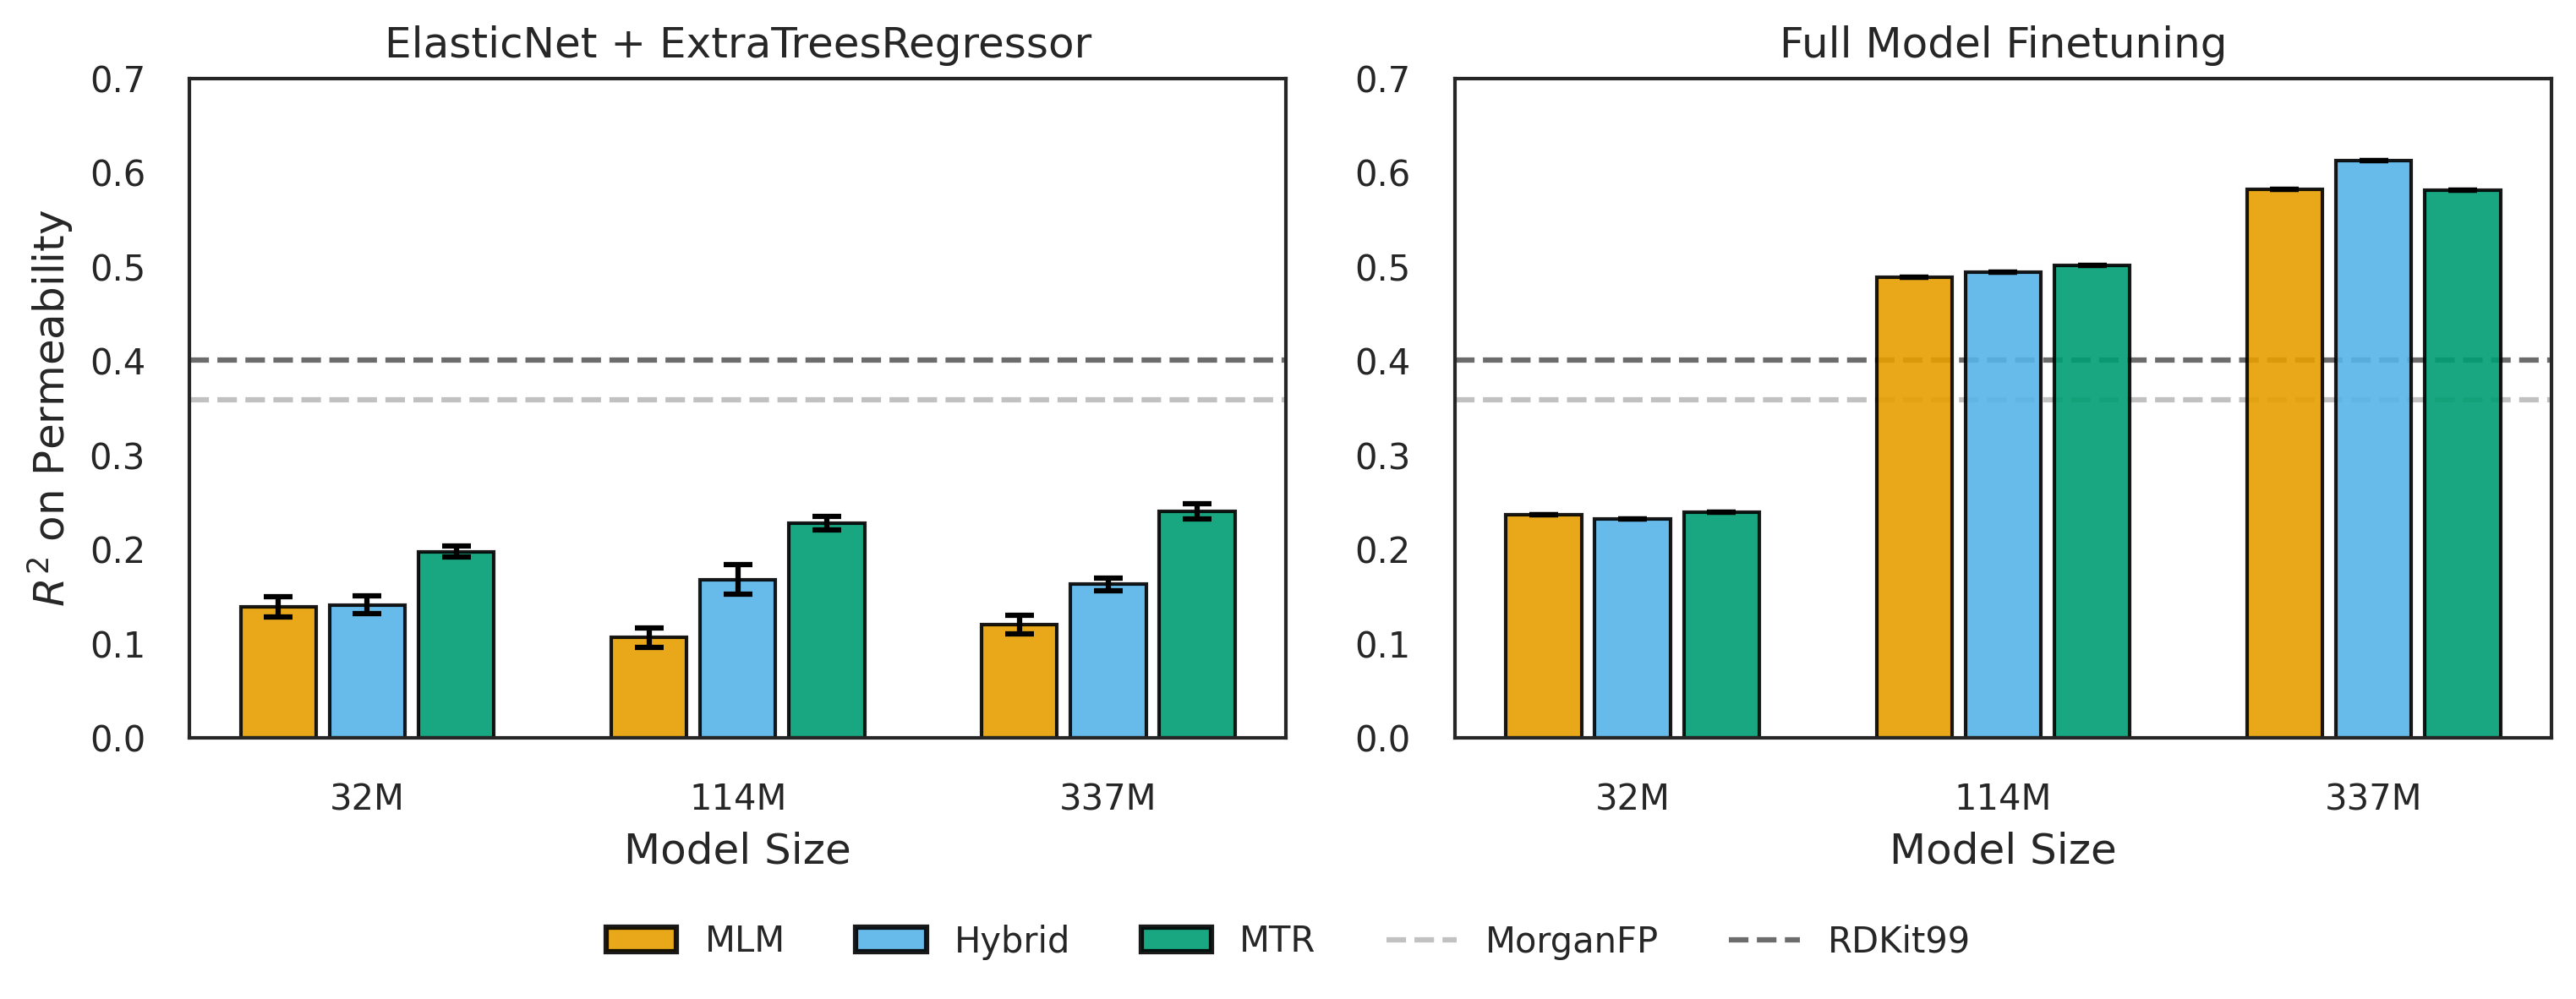

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Global Plot Layout Configuration ---
BAR_ALLOCATION_WIDTH = 0.24  # Total space allocated for each bar's slot
VISUAL_BAR_SCALE = 0.85      # Scale factor (< 1.0 creates gaps between bars)

PLOT_COLORS = ["#E69F00", "#56B4E9", "#009E73"]
BASELINE_COLORS = ["#C1C1C1", "#6C6C6C"]
BASELINE_LABELS = ["MorganFP", "RDKit99"]

MODEL_LABELS = {
    "MLM": "MLM",
    "MLM-MTR": "Hybrid",
    "MTR": "MTR",
}

MODEL_ORDER = ["MLM", "MLM-MTR", "MTR"]
GROUP_ORDER = ["32M", "114M", "337M"]

def plot_permeability_bars(transfer_df, finetune_df, morgan_r2, rdkit_r2, id_label=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4), dpi=300)
    
    x_positions = np.arange(len(GROUP_ORDER), dtype=float)
    total_bars = len(MODEL_ORDER)
    max_offset = BAR_ALLOCATION_WIDTH * (total_bars - 1) / 2
    offsets = np.linspace(-max_offset, max_offset, num=total_bars)
    
    baseline_vals = [morgan_r2, rdkit_r2]

    for ax in [ax1, ax2]:
        ax.spines['top'].set_linewidth(1)
        ax.spines['right'].set_linewidth(1)
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)
        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

    # --- 1. Draw Baselines Edge-to-Edge Behind Bars (Low Z-order) ---
    for ax in [ax1, ax2]:
        for b_idx, base_val in enumerate(baseline_vals):
            # axhline automatically spans 100% of the bounding box width
            ax.axhline(
                y=base_val,
                color=BASELINE_COLORS[b_idx],
                linestyle="dashed",
                linewidth=1.5,
                zorder=1,
            )

    # --- 2. Populate Subplot 1: Transfer Learning ---
    for i, model_name in enumerate(MODEL_ORDER):
        color = PLOT_COLORS[i % len(PLOT_COLORS)]
        label = MODEL_LABELS.get(model_name, model_name)

        heights = []
        errors = []
        for group_name in GROUP_ORDER:
            row = transfer_df.loc[
                (transfer_df["Model"] == group_name) & (transfer_df["Training_method"] == model_name)
            ]
            if row.empty:
                heights.append(np.nan)
                errors.append(np.nan)
            else:
                heights.append(float(row.iloc[0]["R2"]))
                errors.append(float(row.iloc[0]["R2_std"]))

        current_x = x_positions + offsets[i]
        
        ax1.bar(
            current_x,
            heights,
            width=BAR_ALLOCATION_WIDTH * VISUAL_BAR_SCALE,
            color=color,
            edgecolor="black",
            linewidth=1,
            alpha=0.9,
            label=label,
            zorder=2,
        )
        ax1.errorbar(
            current_x,
            heights,
            yerr=errors,
            fmt="none",
            ecolor="black",
            elinewidth=1.5,
            capsize=4,
            capthick=1.5,
            zorder=3,
        )

    # --- 3. Populate Subplot 2: Finetuning ---
    for i, model_name in enumerate(MODEL_ORDER):
        color = PLOT_COLORS[i % len(PLOT_COLORS)]
        label = MODEL_LABELS.get(model_name, model_name)

        heights = []
        errors = []
        for group_name in GROUP_ORDER:
            row = finetune_df.loc[
                (finetune_df["Model"] == group_name) & (finetune_df["Training_method"] == model_name)
            ]
            if row.empty:
                heights.append(np.nan)
                errors.append(np.nan)
            else:
                heights.append(float(row.iloc[0]["R2"]))
                errors.append(float(row.iloc[0]["R2_std"]))

        current_x = x_positions + offsets[i]
        
        ax2.bar(
            current_x,
            heights,
            width=BAR_ALLOCATION_WIDTH * VISUAL_BAR_SCALE,
            color=color,
            edgecolor="black",
            linewidth=1,
            alpha=0.9,
            label=label,
            zorder=2,
        )
        ax2.errorbar(
            current_x,
            heights,
            yerr=errors,
            fmt="none",
            ecolor="black",
            elinewidth=1.5,
            capsize=4,
            capthick=1.5,
            zorder=3,
        )

    # --- Axes Adjustments and Label Styling ---
    ax1.set_title("ElasticNet + ExtraTreesRegressor", loc="center", fontsize=12)
    ax1.set_ylabel(r"$R^2$ on Permeability", fontsize=12)
    ax1.set_ylim(0, 0.7)
    
    ax2.set_title("Full Model Finetuning", loc="center", fontsize=12)
    ax2.set_ylabel(None)
    ax2.set_ylim(0, 0.7)

    for ax in [ax1, ax2]:
        ax.set_xticks(x_positions)
        ax.set_xticklabels(GROUP_ORDER, rotation=0, ha="center")
        ax.set_xlabel("Model Size", fontsize=12)
        # Give x-axis margins slight padding so edge bars don't clip the outer borders
        ax.set_xlim(x_positions[0] - max_offset - BAR_ALLOCATION_WIDTH, x_positions[-1] + max_offset + BAR_ALLOCATION_WIDTH)

    # --- Clean Unified Legend ---
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=PLOT_COLORS[0], edgecolor="black", alpha=0.9, label="MLM"),
        plt.Rectangle((0, 0), 1, 1, facecolor=PLOT_COLORS[1], edgecolor="black", alpha=0.9, label="Hybrid"),
        plt.Rectangle((0, 0), 1, 1, facecolor=PLOT_COLORS[2], edgecolor="black", alpha=0.9, label="MTR"),
        plt.Line2D([0], [0], color=BASELINE_COLORS[0], lw=1.5, linestyle="--", label="MorganFP"),
        plt.Line2D([0], [0], color=BASELINE_COLORS[1], lw=1.5, linestyle="--", label="RDKit99"),
    ]

    fig.legend(
        handles=legend_handles,
        title=None,
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=5,
        fontsize=10,
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.85, hspace=0.25)
    
    plt.savefig("figures/fig3DE_membrane_permeation.svg", bbox_inches="tight", dpi=300)
    plt.savefig("figures/fig3DE_membrane_permeation.pdf", bbox_inches="tight", dpi=300)
    plt.show()

# Run function execution
plot_permeability_bars(transfer_df, finetune_df, morgan_r2, rdkit_r2)

In [ ]:
import numpy as np
import pandas as pd
import plotnine as p9
from plotnine import (
    ggplot,
    aes,
    geom_violin,
    geom_sina,
    geom_hline,
    scale_fill_manual,
    scale_color_manual,
    labs,
    theme_classic,
    theme
)

# Sample Data Creation (Replace this with actual data loading)
df = pd.read_csv('figure_data/fig3D_lasso_predictions.csv')

# sort by Model (small, base, large)
df['Model'] = pd.Categorical(
    df['Model'], 
    categories=['small', 'base', 'large'], 
    ordered=True
)

# 2. Define Custom Colors
# We need three colors for the fill (lighter) and three for the outline (darker)

outline_colors = [
    "#39a1db", 
    "#E69F00", 
    "#009E73"
    ] # Darker shades for outline/sina points

fill_colors = [
    "#91caeb", 
    "#edc264", 
    "#82cfba"
    ] # Light shades for fill

# Combine colors into a single dictionary for easier mapping (optional, but clean)
color_map = {
    'MLM_only': {'fill': fill_colors[0], 'outline': outline_colors[0]},
    'MLM-MTR': {'fill': fill_colors[1], 'outline': outline_colors[1]},
    'MTR_only': {'fill': fill_colors[2], 'outline': outline_colors[2]}
}

# Extract lists for plotnine
fill_list = [v['fill'] for v in color_map.values()]
outline_list = [v['outline'] for v in color_map.values()]

# 3. Create the Plot
plot = (
    ggplot(df, aes(x='Model', y='R2', fill='Training_method', color='Training_method'))
    # MFP Benchmark Line (0.393, Red Dashed)
    + geom_hline(
        yintercept=0.303,
        linetype='dashed',
        size=1,
        color='#6C6C6C'  # Explicitly set to red
    )
    # RDKit99 Benchmark Line (0.196, Black Dashed)
    + geom_hline(
        yintercept=0.196,
        linetype='dashed',
        size=1,
        color='#C1c1c1' # Explicitly set to black
    )
    + geom_violin(
        # The outline border color of the violin
        aes(fill='Training_method', color='Training_method'),
        style='full',
        size=0.8,
        show_legend=True
    )
    + geom_sina(
        aes(color='Training_method'),
        # remove last layer points
        data=df[df['Layer'] != df.groupby(['Model', 'Training_method'])['Layer'].transform('max')],
        # fill points for the sina plot should be solid outline_colors
        size=2,
        alpha=1,
        show_legend=False,
        # fill cannot just be set to outline_colors here, must be mapped via aes()
    )
    # add a black dot for the last layer of each model and training method
    + geom_sina(
        data=df.groupby(['Model', 'Training_method']).apply(lambda x: x.nlargest(1, 'Layer')).reset_index(drop=True),
        mapping=aes(x='Model', y='R2'),
        color='black',
        size=2.5,
        alpha=1,
        show_legend=False,
    )
    
    # Custom color scales for Fill and Outline/Sina
    + scale_fill_manual(values=fill_list)
    + scale_color_manual(values=outline_list)
    # make x-ticks font larger
    
    # Labels and Theme
    + labs(
        title='',
        y='R2 Metric',
        x=''
    )
    
    # add plot size
    + theme_classic()
)

# 4. Display/Save the Plot
plot = plot+theme(
    legend_position=(0.9, 0.1),
    axis_text_x=p9.element_text(size=12, color='black'),
    # change Training_method legend title to 'Training Method'
    legend_title=p9.element_text(text='Training Method'),
    )
# plot.save('figures/figS3_LassoCV_Sina_plot.svg', width=8/1.5, height=6/1.5, dpi=300) # Uncomment to save
# plot.save('figures/figS3_LassoCV_Sina_plot.pdf', width=8/1.5, height=6/1.5, dpi=300) # Uncomment to save
plot.show()

PlotnineError: "Could not evaluate the 'x' mapping: 'Model' (original error: name 'Model' is not defined)"

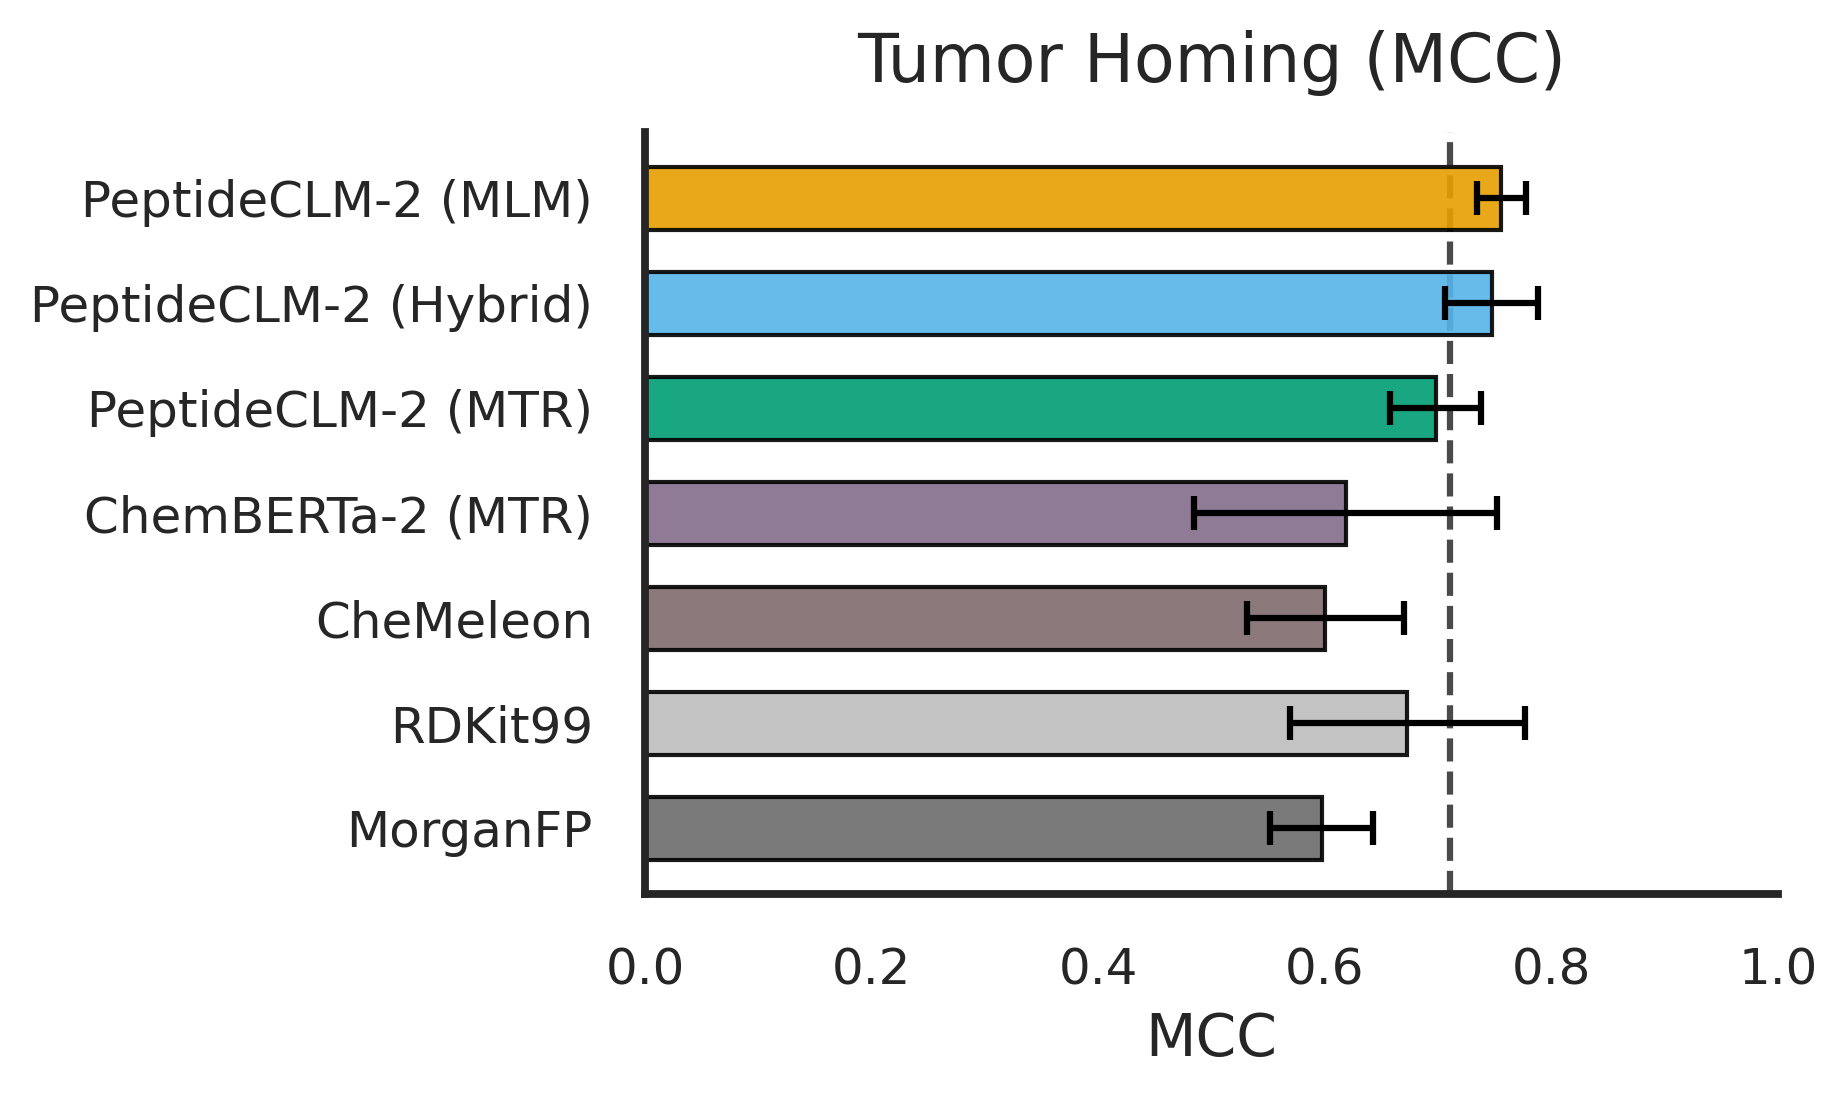

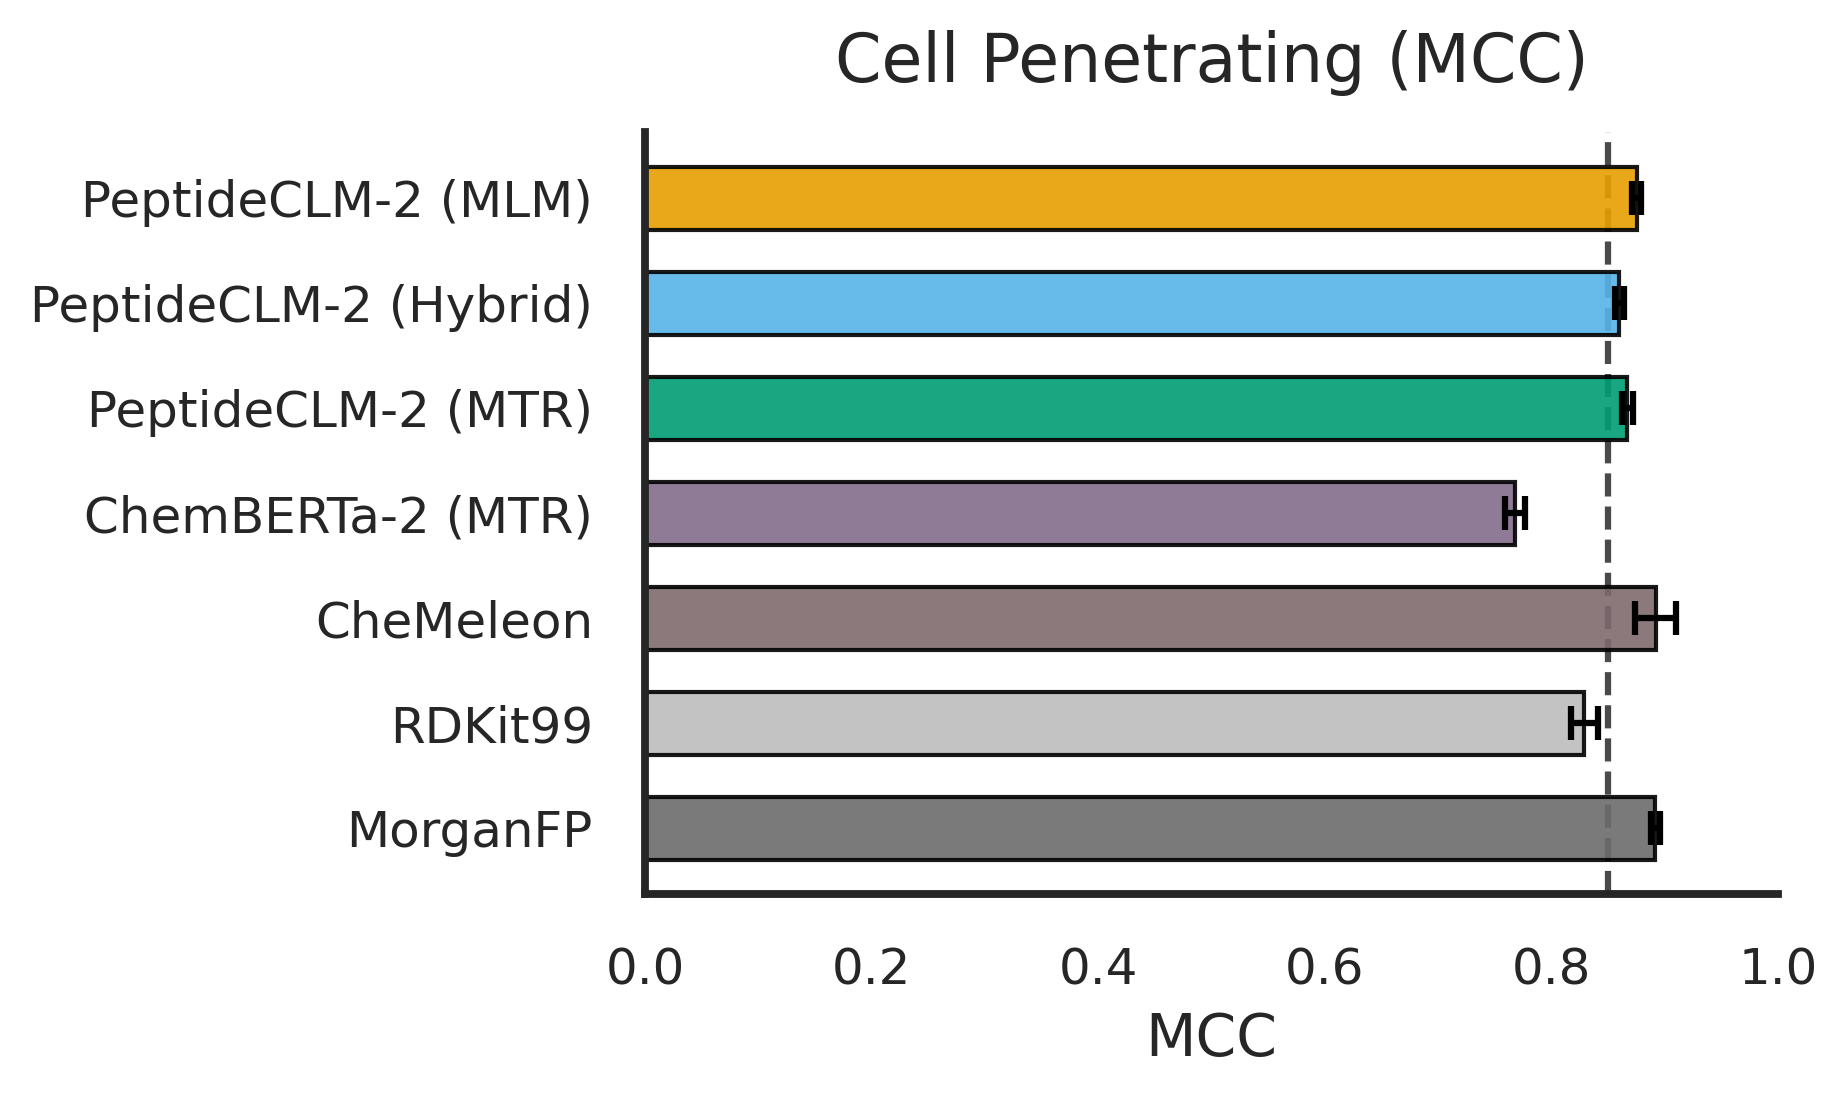

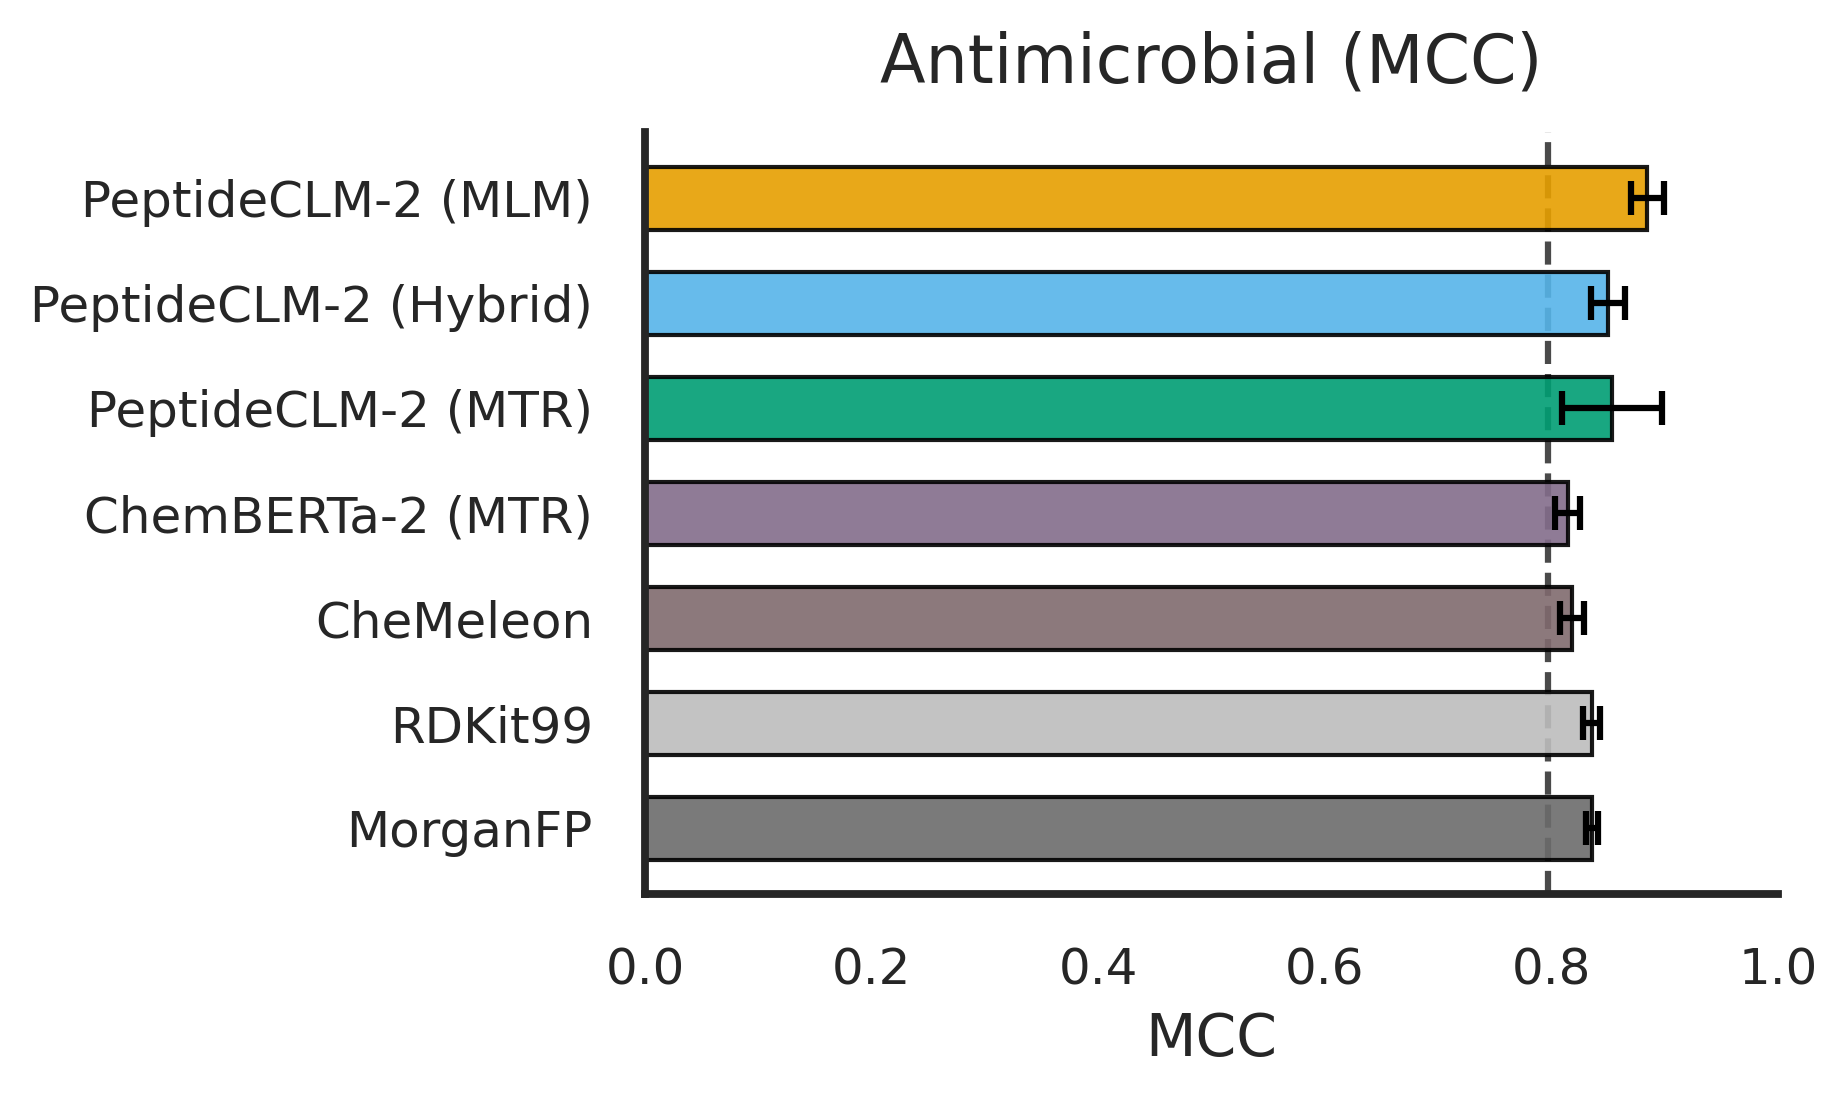

,Task,Model,mean_score,std_score,n,ci95
0,Antimicrobial (MCC),CheMeleon,0.817679,0.009312,3,0.010538
1,Antimicrobial (MCC),ChemBERTa-2 (MTR),0.814117,0.009694,3,0.010970
2,Antimicrobial (MCC),MorganFP,0.835625,0.004904,3,0.005549
3,Antimicrobial (MCC),PeptideCLM-2 (Hybrid),0.849705,0.013518,3,0.015298
4,Antimicrobial (MCC),PeptideCLM-2 (MLM),0.884437,0.012887,3,0.014583
5,Antimicrobial (MCC),PeptideCLM-2 (MTR),0.853104,0.039001,3,0.044134
6,Antimicrobial (MCC),RDKit99,0.835433,0.006588,3,0.007455
7,Cell Penetrating (MCC),CheMeleon,0.891663,0.015725,3,0.017794
8,Cell Penetrating (MCC),ChemBERTa-2 (MTR),0.767796,0.007732,3,0.008749
9,Cell Penetrating (MCC),MorganFP,0.891467,0.003375,3,0.003819


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="talk")

results_root = Path("results") / "runs_LoRA_highrank"
all_csv_paths = sorted(results_root.glob("*_all.csv"))

if not all_csv_paths:
    raise FileNotFoundError(f"No *_all.csv files found under {results_root.resolve()}")

raw_df = pd.concat((pd.read_csv(p) for p in all_csv_paths), ignore_index=True)

# Keep only test MCC values, one row per task/model/seed.
mcc_df = raw_df.loc[
    (raw_df["split_id"] == "test") & (raw_df["metric_name"] == "mcc"),
    ["task_id", "model_variant", "seed", "metric_value"],
]

task_label_map = {
    "thpep": "Tumor Homing (MCC)",
    "cellppd": "Cell Penetrating (MCC)",
    "amp_hgt": "Antimicrobial (MCC)",
}

# Prior-method baselines from the publication summary table.
prior_baseline_map = {
    "Tumor Homing (MCC)": 0.71,
    "Cell Penetrating (MCC)": 0.85,
    "Antimicrobial (MCC)": 0.797,
}

model_label_map = {
    "peptideclm-2-mlm-large": "PeptideCLM-2 (MLM)",
    "peptideclm-2-hybrid-large": "PeptideCLM-2 (Hybrid)",
    "peptideclm-2-mtr-large": "PeptideCLM-2 (MTR)",
    "ChemBERTa-77M-MTR": "ChemBERTa-2 (MTR)",
    "CheMeleon": "CheMeleon",
    "xgboost-morgan": "MorganFP",
    "xgboost-rdkit": "RDKit99",
}

mcc_df["Task"] = mcc_df["task_id"].map(task_label_map)
mcc_df["Model"] = mcc_df["model_variant"].map(model_label_map)
mcc_df = mcc_df.dropna(subset=["Task", "Model"]).copy()

summary_df = (
    mcc_df.groupby(["Task", "Model"], as_index=False)
    .agg(
        mean_score=("metric_value", "mean"),
        std_score=("metric_value", "std"),
        n=("metric_value", "size"),
    )
)
summary_df["std_score"] = summary_df["std_score"].fillna(0.0)
summary_df["ci95"] = 1.96 * summary_df["std_score"] / np.sqrt(summary_df["n"].clip(lower=1))

task_order = [
    "Tumor Homing (MCC)",
    "Cell Penetrating (MCC)",
    "Antimicrobial (MCC)",
]

model_order = [
    "PeptideCLM-2 (MLM)",
    "PeptideCLM-2 (Hybrid)",
    "PeptideCLM-2 (MTR)",
    "ChemBERTa-2 (MTR)",
    "CheMeleon",
    "RDKit99",
    "MorganFP",
]


#PLOT_COLORS = ["#E69F00", "#56B4E9", "#009E73"]
model_colors = {
    "PeptideCLM-2 (MLM)": "#E69F00",
    "PeptideCLM-2 (Hybrid)": "#56B4E9",
    "PeptideCLM-2 (MTR)": "#009E73",
    "ChemBERTa-2 (MTR)": "#836D8B",
    "CheMeleon": "#806A6E",
    "MorganFP": "#6C6C6C",
    "RDKit99": "#BDBDBD",
}

fig_labels = {
    "Tumor Homing (MCC)": "B",
    "Cell Penetrating (MCC)": "D",
    "Antimicrobial (MCC)": "F",
}

for task in task_order:
    plot_df = summary_df.loc[summary_df["Task"] == task].copy()
    plot_df["Model"] = pd.Categorical(plot_df["Model"], categories=model_order, ordered=True)
    plot_df = plot_df.sort_values("Model")

    y_positions = np.arange(len(plot_df))
    x_values = plot_df["mean_score"].to_numpy()
    x_errors = plot_df["ci95"].to_numpy()
    labels = plot_df["Model"].tolist()
    colors = [model_colors[m] for m in labels]

    fig, ax = plt.subplots(figsize=(6.5, 4.0), dpi=300)
    
    # Draw prior baseline as a vertical reference line behind the bars
    ax.axvline(
        prior_baseline_map[task],
        color="#4A4A4A",
        linestyle="--",
        linewidth=1.5,
        zorder=1
    )

    # Convert to horizontal bar plot using barh
    ax.barh(
        y_positions,
        x_values,
        xerr=x_errors,
        height=0.6,
        color=colors,
        edgecolor="black",
        alpha=0.9,
        linewidth=1,
        error_kw={"ecolor": "black", "capsize": 4, "elinewidth": 1.5, "capthick": 1.5},
        zorder=2
    )

    # Invert the y-axis to read model_order from top to bottom
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=12)
    ax.invert_yaxis()

    ax.set_title(task, fontsize=16, pad=12)
    ax.set_xlabel("MCC", fontsize=14)
    ax.set_ylabel("")
    ax.set_xlim(0, 1.0)
    ax.tick_params(axis="x", labelsize=12)
    
    sns.despine(ax=ax)
    plt.tight_layout()

    # file_base = task.split('(')[0].strip().replace(' ', '_')
    # plt.savefig(f"figures/fig4{fig_labels[task]}_{file_base}_barplot.svg", bbox_inches="tight", dpi=300)
    # plt.savefig(f"figures/fig4{fig_labels[task]}_{file_base}_barplot.pdf", bbox_inches="tight", dpi=300)
    plt.show()

display(summary_df.sort_values(["Task", "Model"]).reset_index(drop=True))

In [1]:
# Generate token embeddings from the model(s)
import pandas as pd
import numpy as np

# load model from huggingface
from transformers import AutoModel, AutoTokenizer
model_name = "aaronfeller/PeptideMLM_lg"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModel.from_pretrained(model_name, trust_remote_code=True)

# import CycPeptMPDB data
df = pd.read_csv('figure_data/fig3ABC_PAMPA_embeddings.csv')


/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
A new version of the following files was downloaded from https://huggingface.co/aaronfeller/PeptideMLM_lg:
- config.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/aaronfeller/PeptideMLM_lg:
- ChemPepMTR.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


In [ ]:
# import torch
# from tqdm import tqdm

# # generate embeddings for all sequences in the dataframe
# embeddings = []
# smiles = df['SMILES'].tolist()
# batch_size = 64

# # model and data to device
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model.to(device)

# for i in tqdm(range(0, len(smiles), batch_size)):
#     batch_smiles = smiles[i:i+batch_size]
#     inputs = tokenizer(batch_smiles, return_tensors="pt", padding=True, truncation=True).to(device)
#     with torch.no_grad():
#         outputs = model(**inputs)
#     # mean pool the token embeddings to get a single embedding per sequence
#     batch_embeddings = outputs['mean_pool'].cpu().numpy()
#     embeddings.extend(batch_embeddings)

# embeddings = np.array(embeddings)
# print("Embeddings shape:", embeddings.shape)

100%|██████████| 105/105 [00:17<00:00,  5.88it/s]

Embeddings shape: (6701, 1024)


In [9]:
# # calculate logp using rdkit 
# from rdkit import Chem
# from rdkit.Chem import Crippen
# from rdkit.Chem import Descriptors

# from tqdm import tqdm

# logp_values = []
# for smi in tqdm(df['SMILES']):
#     mol = Chem.MolFromSmiles(smi)
#     logp = Crippen.MolLogP(mol)
#     logp_values.append(logp)

# df['LogP'] = logp_values

# # calculate number of atoms using rdkit
# num_atoms = []
# for smi in tqdm(df['SMILES']):
#     mol = Chem.MolFromSmiles(smi)
#     n_atoms = Descriptors.HeavyAtomCount(mol)
#     num_atoms.append(n_atoms)
# df['Num_Atoms'] = num_atoms

# MolWts = []
# for smi in tqdm(df['SMILES']):
#     mol = Chem.MolFromSmiles(smi)
#     MolWt = Descriptors.ExactMolWt(mol)
#     MolWts.append(MolWt)
# df['MolWt'] = MolWts

# maxAbsPartialCharge = []
# minAbsPartialCharge = []
# MaxPartialCharge = []
# MinPartialCharge = []

# for smi in tqdm(df['SMILES']):
#     mol = Chem.MolFromSmiles(smi)
#     Chem.rdPartialCharges.ComputeGasteigerCharges(mol)
#     charges = [float(atom.GetProp('_GasteigerCharge')) for atom in mol.GetAtoms()]
#     maxAbsPartialCharge.append(max(abs(charge) for charge in charges))
#     minAbsPartialCharge.append(min(abs(charge) for charge in charges))
#     MaxPartialCharge.append(max(charges))
#     MinPartialCharge.append(min(charges))
# df['MaxAbsPartialCharge'] = maxAbsPartialCharge
# df['MinAbsPartialCharge'] = minAbsPartialCharge
# df['MaxPartialCharge'] = MaxPartialCharge
# df['MinPartialCharge'] = MinPartialCharge

# # calculate NumRotatableBonds, NumAliphatic/AromaticRings, TPSA, Nchiral, and NumHDonors/Acceptors using rdkit
# NumRotatableBonds = []
# NumAliphaticRings = []
# NumAromaticRings = []
# TPSA = []
# Nchiral = []
# NumHDonors = []
# NumHAcceptors = []

# for smi in tqdm(df['SMILES']):
#     mol = Chem.MolFromSmiles(smi)
#     NumRotatableBonds.append(Descriptors.NumRotatableBonds(mol))
#     NumAliphaticRings.append(Descriptors.NumAliphaticRings(mol))
#     NumAromaticRings.append(Descriptors.NumAromaticRings(mol))
#     TPSA.append(Descriptors.TPSA(mol))
#     Nchiral.append(len(Chem.FindMolChiralCenters(mol, includeUnassigned=True)))
#     NumHDonors.append(Descriptors.NumHDonors(mol))
#     NumHAcceptors.append(Descriptors.NumHAcceptors(mol))
# df['NumRotatableBonds'] = NumRotatableBonds
# df['NumAliphaticRings'] = NumAliphaticRings
# df['NumAromaticRings'] = NumAromaticRings
# df['TPSA'] = TPSA
# df['Nchiral'] = Nchiral
# df['NumHDonors'] = NumHDonors
# df['NumHAcceptors'] = NumHAcceptors


In [ ]:
# # use tsne to reduce the embeddings to 2D
# from sklearn.manifold import TSNE

# tsne = TSNE(n_components=2, perplexity=30, max_iter=1000)
# embeddings_2d = tsne.fit_transform(embeddings)
# print("2D Embeddings shape:", embeddings_2d.shape)
# # add the 2D embeddings to the dataframe
# df['t-SNE1'] = embeddings_2d[:, 0]
# df['t-SNE2'] = embeddings_2d[:, 1]

# # print
# print(df.head())

# # save the dataframe to a csv
# df.to_csv("figure_data/fig3ABC_PAMPA_MLM_embeddings.csv", index=False)


2D Embeddings shape: (6701, 2)
                                              SMILES  PAMPA  cluster    LogP  \
0  CCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N(Cc2ccccc2)...  -5.13        1  3.3899   
1  CC(C)C[C@H]1C(=O)N[C@@H](Cc2ccccc2)C(=O)N2CCC[...  -5.63        1  3.5759   
2  CCCN1CC(=O)N[C@@H](CC(C)C)C(=O)N(Cc2ccccc2)CC(...  -5.75        1  3.0387   
3  CC(C)C[C@H]1C(=O)N(Cc2ccccc2)CC(=O)N2CCC[C@H]2...  -5.26        1  2.6470   
4  CCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N(C)[C@H](CC...  -4.78        1  3.5674   

   Num_Atoms       MolWt  MaxAbsPartialCharge  MinAbsPartialCharge  \
0         53  730.441784             0.342504              0.00168   
1         63  861.478897             0.350975              0.00168   
2         59  813.478897             0.342748              0.00168   
3         58  799.463247             0.342792              0.00168   
4         59  821.541498             0.342180              0.00168   

   MaxPartialCharge  MinPartialCharge  NumRotatableBonds  NumAlipha

In [7]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

def create_batlow_cmap(name='batlow', N=256):
    # 1. Define the RGB color stops for the cmap Batlow10
    batlow_colors = [
        "#011959",
        "#103F60",
        "#1C5A62",
        "#3C6D56",
        "#687B3E",
        "#9D892B",
        "#D29343",
        "#F8A17B",
        "#FDB7BC",
        "#FACCFA"
    ]

    # 2. Create the LinearSegmentedColormap object
    cmap = LinearSegmentedColormap.from_list(name, batlow_colors, N=N)
    
    # 3. Register the colormap with Matplotlib
    # This allows you to call it directly by name in plt.colormaps() or in plot code.
    mpl.colormaps.register(cmap=cmap, name=name, force=True)
    
    print(f"Colormap '{name}' registered successfully.")
    return cmap

# 1. Run the function to define and register the colormap:
batlow_cmap = create_batlow_cmap()


Colormap 'batlow' registered successfully.


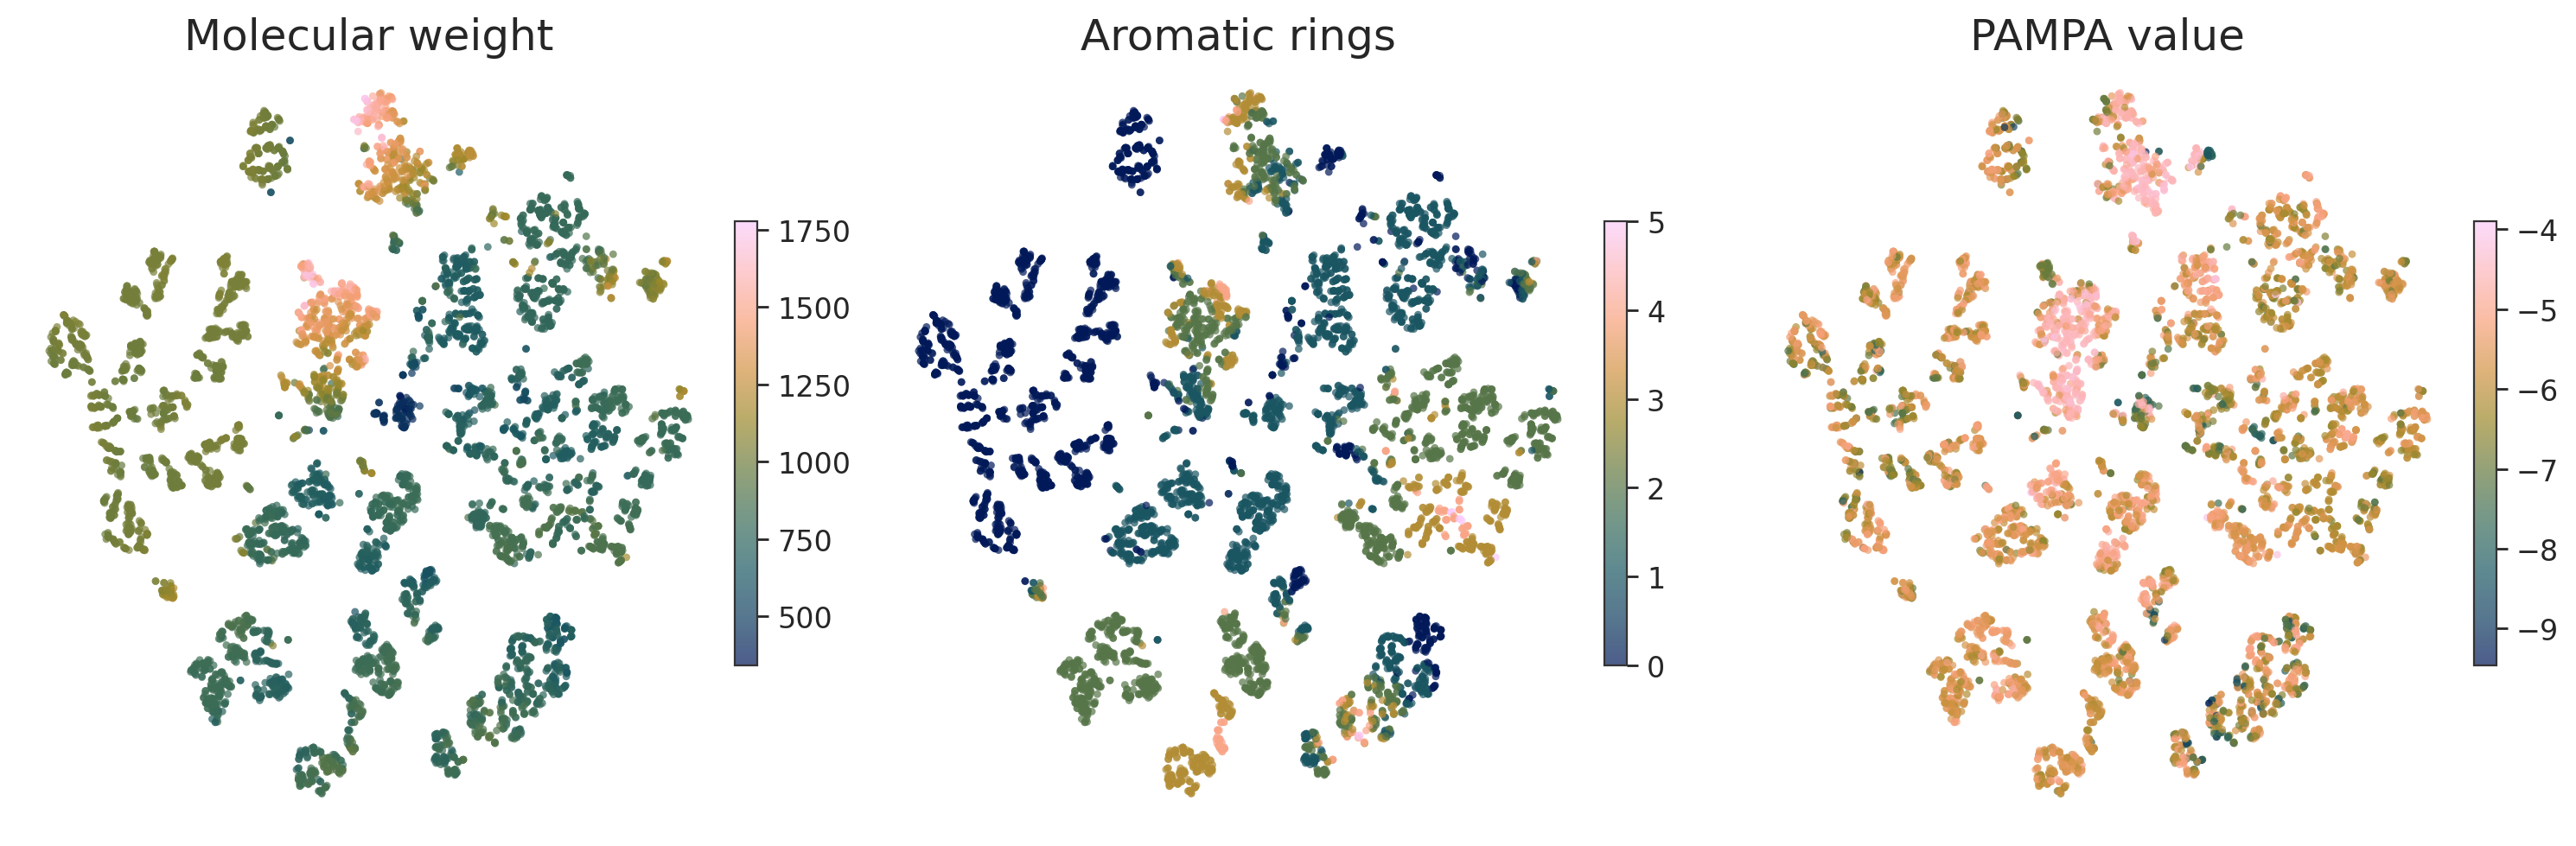

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
# Assuming 'df' (DataFrame) is loaded elsewhere
df = pd.read_csv('figure_data/fig3ABC_PAMPA_MLM_embeddings.csv')


# --- 1. Aesthetic Setup ---
def setup_plot_aesthetics(font_family="Arial", font_size=10):
    """Sets aesthetic parameters optimized for a dense grid layout."""
    # Use 'paper' context for smaller, denser plots
    sns.set_theme(style="white", context="paper") 
    plt.rcParams.update({
        # "font.family": "sans-serif",
        # "font.sans-serif": [font_family],
        "axes.linewidth": 0.8,
        "axes.edgecolor": "0.2",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "font.size": font_size
    })

# --- 2. Core Plotting Function ---
def plot_tsne_panel(ax, df, color_col, cmap=None): # cmap options: "coolwarm", "viridis", "plasma", "inferno", "magma", "cividis"
    """Generates a single t-SNE scatter plot panel with a colorbar."""
    scatter = ax.scatter(
        df["t-SNE1"],
        df["t-SNE2"],
        c=df[color_col],
        cmap=cmap,
        s=10, # Smaller points for dense view
        alpha=0.7,
        edgecolors="none"
    )

    # Labeling and Clean-up for dense panel
    ax.set_title(color_col, fontsize=18, pad=2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("") # Remove labels to save space
    ax.set_ylabel("")
    sns.despine(ax=ax, left=True, bottom=True)
    
    return scatter

# --- 3. Generate 3x5 Multi-Panel Figure ---

plot_colorbars = [
    "MolWt", "NumAromaticRings", "PAMPA"

    # "PAMPA", "LogP", "Num_Atoms", "MolWt", 
    # "MaxAbsPartialCharge", "MinAbsPartialCharge", 
    # "MaxPartialCharge", "MinPartialCharge", 
    # "NumRotatableBonds", "NumAliphaticRings", 
    # "NumAromaticRings", "TPSA", "Nchiral", 
    # "NumHDonors", "NumHAcceptors"
]

colors = [
    'batlow',
    'batlow',
    'batlow',
]
# Set up aesthetics
setup_plot_aesthetics() 

# Create the 3x5 figure layout (15 columns wide, 9 high is a good starting size)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=200)
axes = axes.flatten() # Flatten the 3x5 array for easy iteration


# Iterate through features and plot to each subplot
for i, col in enumerate(plot_colorbars):
    ax = axes[i]
    scatter_obj = plot_tsne_panel(
        ax, 
        df, # Assuming 'df' is available in the environment
        color_col=col,
        cmap=colors[i]
    )
    
    # Add a thin colorbar for each plot
    cbar = plt.colorbar(scatter_obj, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=12)
    if col in ["MolWt"]:
        cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))
    elif col in ["NumAliphaticRings"]:
        cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    elif col in ["MaxAbsPartialCharge"]:
        cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

    # change facet titles

    updated_cols = {
        "MolWt": "Molecular weight",
        "NumAromaticRings": "Aromatic rings",
        "PAMPA": "PAMPA value"
    }
    col = updated_cols.get(col, col)

    ax.set_title(col, fontsize=18, pad=2)

# Adjust spacing between plots
plt.tight_layout(w_pad=1.5, h_pad=2.0)
# plt.suptitle("Exploratory t-SNE Embeddings (Colored by Physicochemical Descriptor)", fontsize=12, y=1.02)
plt.savefig("figures/fig3ABC_PAMPA_MLM_embeddings.svg", bbox_inches="tight", dpi=300)
plt.savefig("figures/fig3ABC_PAMPA_MLM_embeddings.pdf", bbox_inches="tight", dpi=300)
plt.savefig("figures/fig3ABC_PAMPA_MLM_embeddings.png", bbox_inches="tight", dpi=300)
plt.show()

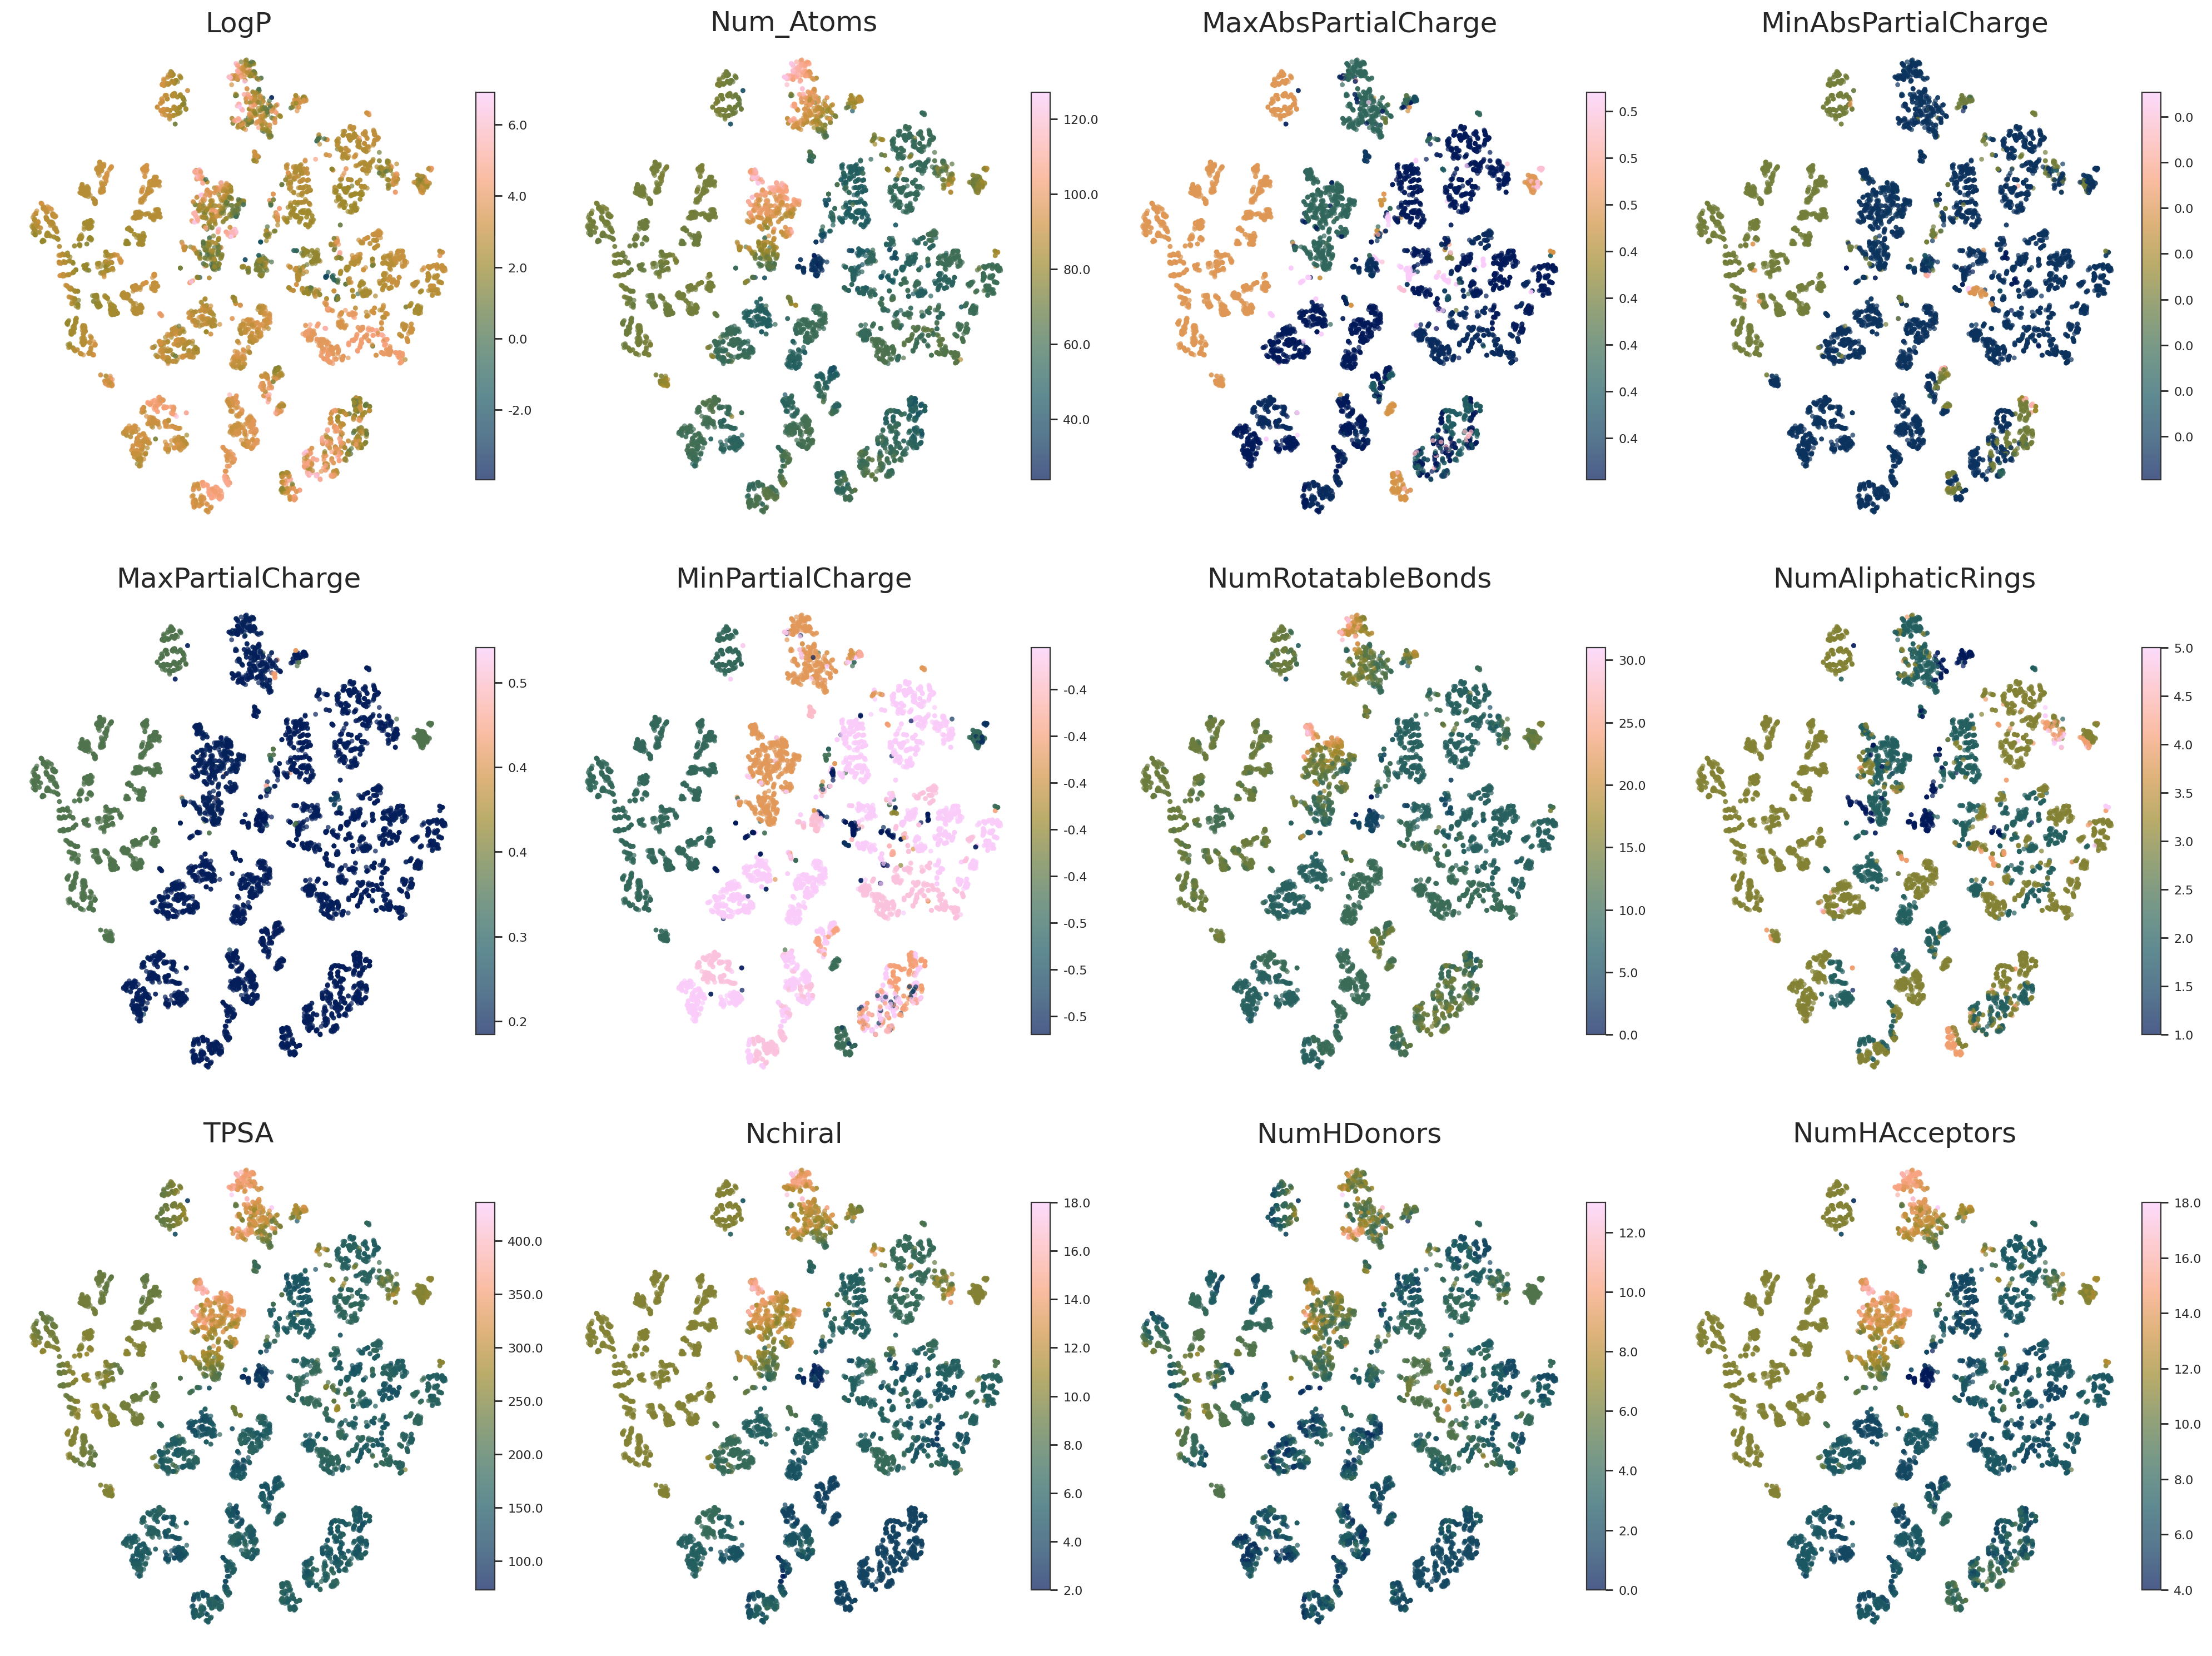

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('figure_data/fig3ABC_PAMPA_MLM_embeddings.csv')

# --- 1. Aesthetic Setup ---
def setup_plot_aesthetics(font_family="Arial", font_size=10):
    """Sets aesthetic parameters optimized for a dense grid layout."""
    # Use 'paper' context for smaller, denser plots
    sns.set_theme(style="white", context="paper") 
    plt.rcParams.update({
        # "font.family": "sans-serif",
        # "font.sans-serif": [font_family],
        "axes.linewidth": 0.8,
        "axes.edgecolor": "0.2",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "font.size": font_size
    })

# --- 2. Core Plotting Function ---
def plot_tsne_panel(ax, df, color_col, cmap="batlow"): # cmap options: "viridis", "plasma", "inferno", "magma", "cividis"
    """Generates a single t-SNE scatter plot panel with a colorbar."""
    scatter = ax.scatter(
        df["t-SNE1"],
        df["t-SNE2"],
        c=df[color_col],
        cmap=cmap,
        s=10, # Smaller points for dense view
        alpha=0.7,
        edgecolors="none"
    )

    # Labeling and Clean-up for dense panel
    ax.set_title(color_col, fontsize=9, pad=2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("") # Remove labels to save space
    ax.set_ylabel("")
    sns.despine(ax=ax, left=True, bottom=True)
    
    return scatter

# --- 3. Generate 3x5 Multi-Panel Figure ---

plot_colorbars = [
    #"PAMPA", 
    "LogP", "Num_Atoms", #"MolWt", 
    "MaxAbsPartialCharge", "MinAbsPartialCharge", 
    "MaxPartialCharge", "MinPartialCharge", 
    "NumRotatableBonds", "NumAliphaticRings", 
    #"NumAromaticRings", 
    "TPSA", "Nchiral", 
    "NumHDonors", "NumHAcceptors"
]

# Set up aesthetics
setup_plot_aesthetics() 

# Create the 3x5 figure layout (15 columns wide, 9 high is a good starting size)
fig, axes = plt.subplots(3, 4, figsize=(20, 15), dpi=200)
axes = axes.flatten() # Flatten the 3x5 array for easy iteration

# Iterate through features and plot to each subplot
for i, col in enumerate(plot_colorbars):
    ax = axes[i]
    scatter_obj = plot_tsne_panel(
        ax, 
        df, # Assuming 'df' is available in the environment
        color_col=col
    )
    
    # Add a thin colorbar for each plot
    cbar = plt.colorbar(scatter_obj, ax=ax, fraction=0.04, pad=0.02)
    cbar.ax.tick_params(labelsize=8)
    cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f')) # Clean up tick format if needed

    ax.set_title(col, fontsize=18, pad=2)


# Adjust spacing between plots
plt.tight_layout(w_pad=1.5, h_pad=2.0)

plt.savefig("figures/figS2_PAMPA_MLM_embeddings.svg", bbox_inches="tight", dpi=300)
plt.savefig("figures/figS2_PAMPA_MLM_embeddings.pdf", bbox_inches="tight", dpi=300)

In [14]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import Crippen
from rdkit.Chem import Descriptors
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
# from transformers import AutoModel, AutoTokenizer
# import torch

# # load model from huggingface
# def load_model(model_name="aaronfeller/PeptideMLM-MTR_lg"):
#     tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
#     model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
#     return model, tokenizer

# model, tokenizer = load_model()

# def generate_embeddings(model, tokenizer, sequences, batch_size=64):
#     embeddings = []
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model.to(device)
#     for i in tqdm(range(0, len(sequences), batch_size)):
#         batch_seq = sequences[i:i+batch_size]
#         inputs = tokenizer(batch_seq, return_tensors="pt", padding=True, truncation=True).to(device)
#         with torch.no_grad():
#             outputs = model(**inputs)
#         # mean pool the token embeddings to get a single embedding per sequence
#         batch_embeddings = outputs['mean_pool'].cpu().numpy()
#         embeddings.extend(batch_embeddings)
#     return np.array(embeddings)


In [16]:
# # calculate logp using rdkit 
# def calculate_descriptors(df, column="SMILES"):
#     logp_values = []
#     num_atoms = []
#     molwts = []
#     maxAbsPartialCharge = []
#     minAbsPartialCharge = []
#     MaxPartialCharge = []
#     MinPartialCharge = []
#     NumRotatableBonds = []
#     NumAliphaticRings = []
#     NumAromaticRings = []
#     TPSA = []
#     Nchiral = []
#     NumHDonors = []
#     NumHAcceptors = []

#     for smi in tqdm(df[column]):
#         mol = Chem.MolFromSmiles(smi)
#         logp_values.append(Crippen.MolLogP(mol))
#         num_atoms.append(Descriptors.HeavyAtomCount(mol))
#         molwts.append(Descriptors.ExactMolWt(mol))
#         Chem.rdPartialCharges.ComputeGasteigerCharges(mol)
#         charges = [float(atom.GetProp('_GasteigerCharge')) for atom in mol.GetAtoms()]
#         maxAbsPartialCharge.append(max(abs(charge) for charge in charges))
#         minAbsPartialCharge.append(min(abs(charge) for charge in charges))
#         MaxPartialCharge.append(max(charges))
#         MinPartialCharge.append(min(charges))
#         NumRotatableBonds.append(Descriptors.NumRotatableBonds(mol))
#         NumAliphaticRings.append(Descriptors.NumAliphaticRings(mol))
#         NumAromaticRings.append(Descriptors.NumAromaticRings(mol))
#         TPSA.append(Descriptors.TPSA(mol))
#         Nchiral.append(len(Chem.FindMolChiralCenters(mol, includeUnassigned=True)))
#         NumHDonors.append(Descriptors.NumHDonors(mol))
#         NumHAcceptors.append(Descriptors.NumHAcceptors(mol))

#     df['LogP'] = logp_values
#     df['Num_Atoms'] = num_atoms
#     df['MolWt'] = molwts
#     df['MaxAbsPartialCharge'] = maxAbsPartialCharge
#     df['MinAbsPartialCharge'] = minAbsPartialCharge
#     df['MaxPartialCharge'] = MaxPartialCharge
#     df['MinPartialCharge'] = MinPartialCharge
#     df['NumRotatableBonds'] = NumRotatableBonds
#     df['NumAliphaticRings'] = NumAliphaticRings
#     df['NumAromaticRings'] = NumAromaticRings
#     df['TPSA'] = TPSA
#     df['Nchiral'] = Nchiral
#     df['NumHDonors'] = NumHDonors
#     df['NumHAcceptors'] = NumHAcceptors
#     return df


In [17]:
# # use tsne to reduce the embeddings to 2D
# def reduce_embeddings_tsne(embeddings, perplexity=30, max_iter=1000):
#     tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=max_iter)
#     return tsne.fit_transform(embeddings)


In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
# Assuming 'df' (DataFrame) is loaded elsewhere

# --- 1. Aesthetic Setup ---
def setup_plot_aesthetics(font_family="Arial", font_size=14):
    """Sets aesthetic parameters optimized for a dense grid layout."""
    sns.set_theme(style="white", context="paper") 
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": [font_family],
        "axes.linewidth": 0.8,
        "axes.edgecolor": "0.2",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "font.size": font_size
    })

def generate_plot(df, axis_to_color, s=50, alpha=0.7, cmap="coolwarm", figname=None, legend_names=None):
    sns.set_theme(style="white", context="talk")
    plt.rcParams.update({
        "axes.linewidth": 0.8,
        "axes.edgecolor": "0.2",   
        "xtick.direction": "in",  # Keeps ticks clean inside the box
        "ytick.direction": "in",
    })

    fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)

    # 1. Enforce a full bounding box around the canvas
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("0.2")

    # Set zorder=2 so scatter stays above grid lines
    scatter = ax.scatter(
        df["t-SNE1"],
        df["t-SNE2"],
        c=df[axis_to_color],
        cmap=cmap,
        s=s,
        alpha=alpha,
        edgecolors="none",
        zorder=2
    )
    
    # 2. Add grey dashed gridlines at structural intervals of 20
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
    
    # Enable labels and tick markers, but draw them small and clean
    ax.tick_params(
        axis='both', 
        which='major', 
        labelsize=12, 
        pad=5,
        bottom=True, 
        left=True, 
        top=False, 
        right=False
    )
    
    ax.grid(
        True,
        which='major',
        axis='both',
        color="#D1D5DB",
        linestyle="--",
        linewidth=0.8,
        zorder=0
    )

    if len(df[axis_to_color].unique()) > 2:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label(axis_to_color, fontsize=12, text="IC50", labelpad=10)
        cbar.ax.yaxis.set_label_position("left")
        cbar.ax.tick_params(labelsize=10)

    if len(df[axis_to_color].unique()) == 2:
        # Extract default legend components
        handles, labels = scatter.legend_elements()
        
        # Reverse both handles and labels to swap the visual ordering
        handles = handles[::-1]
        labels = labels[::-1]
        
        legend1 = ax.legend(handles, labels, title=None)
        legend1.get_frame().set_alpha(0.3)
        
        # Apply custom naming mapping if it was supplied
        if legend_names:
            # We must map names to match our newly reversed index order
            reversed_names = legend_names[::-1]
            for text, name in zip(legend1.get_texts(), reversed_names):
                text.set_text(name)
                
        ax.add_artist(legend1)

    ax.set_xlabel("t-SNE 1", fontsize=17, labelpad=6)
    ax.set_ylabel("t-SNE 2", fontsize=17, labelpad=6)

    plt.tight_layout()
    if figname:
        plt.savefig(figname, bbox_inches="tight", dpi=300)
    else:
        plt.show()

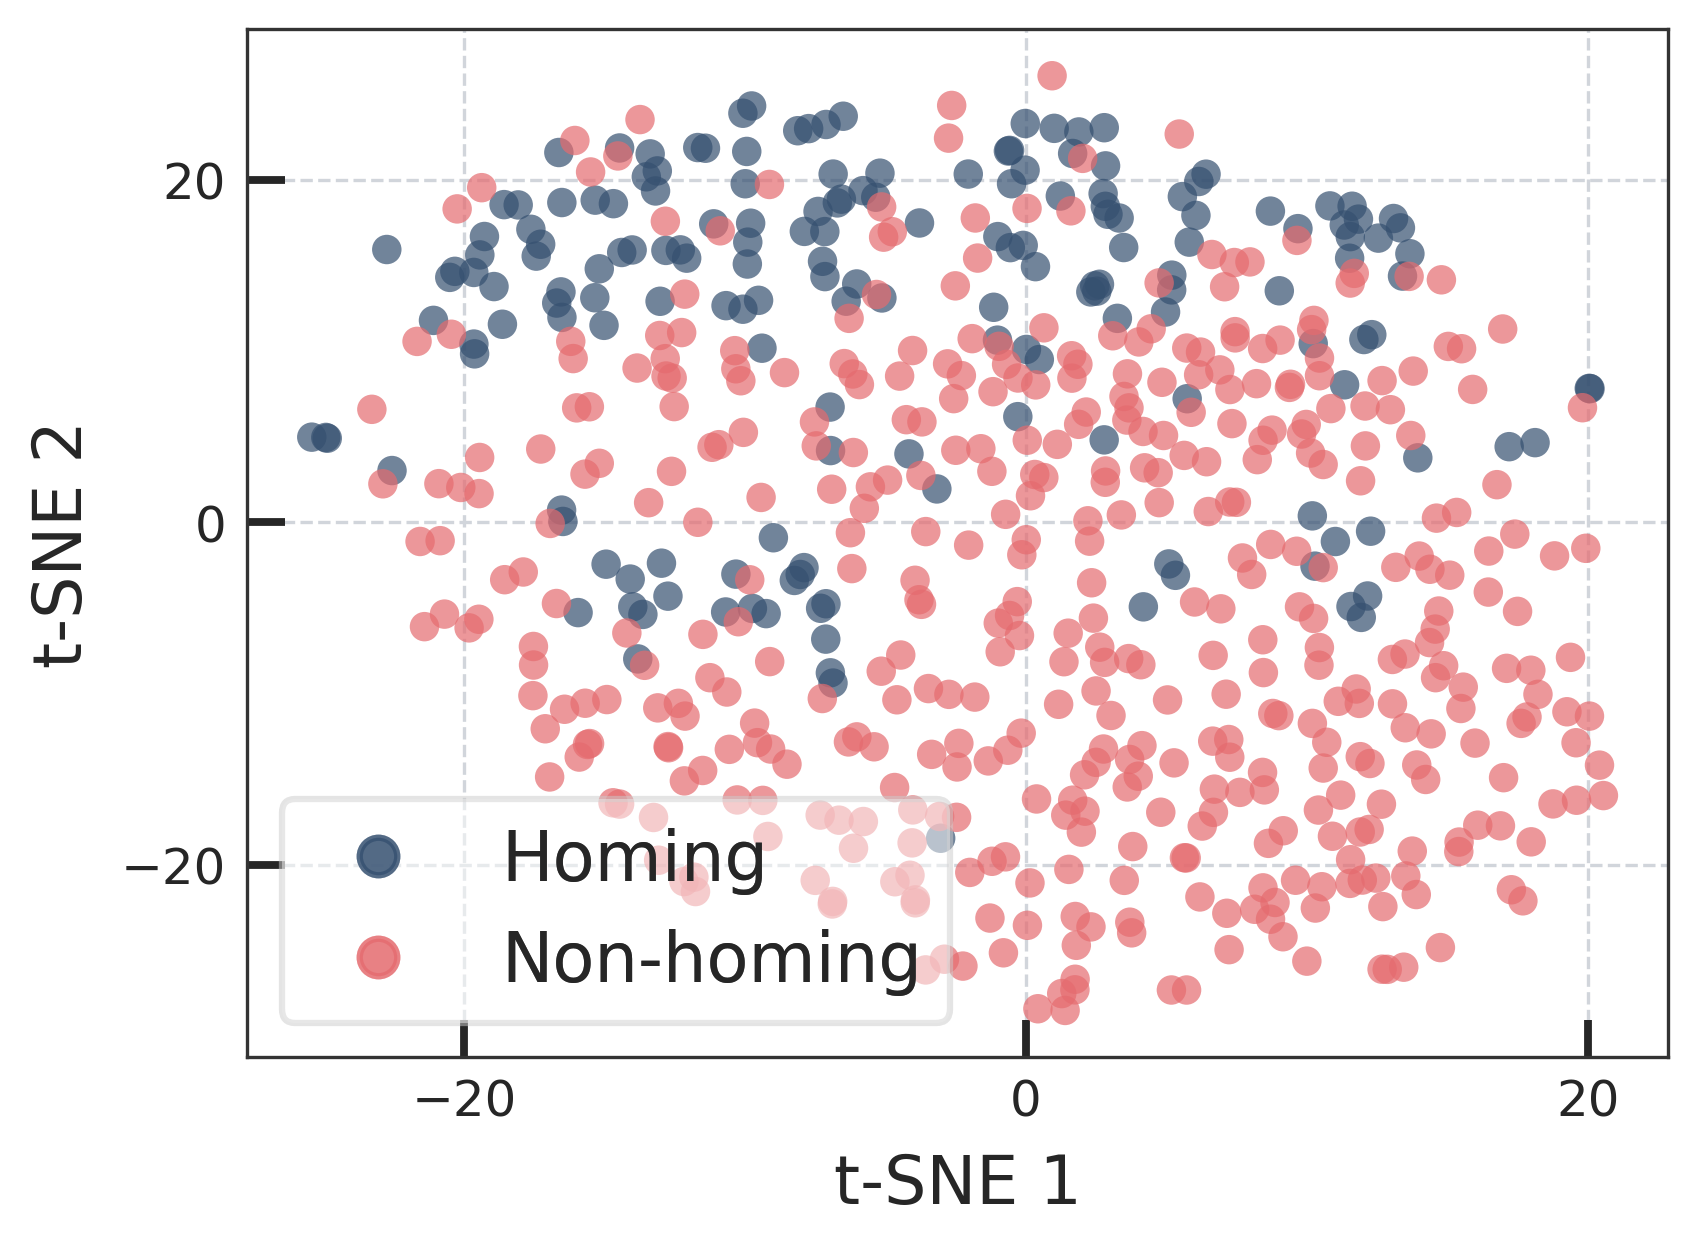

In [14]:
import pandas as pd
from matplotlib.colors import ListedColormap
# # import THPep data
# df_THPep = pd.read_csv('../data/THPep_main90_smiles_classes.csv')

# # generate embeddings for THPep data
# embeddings_THPep = generate_embeddings(model, tokenizer, df_THPep['smiles'].tolist())
# embeddings_THPep_2d = reduce_embeddings_tsne(embeddings_THPep)
# df_THPep['t-SNE1'] = embeddings_THPep_2d[:, 0]
# df_THPep['t-SNE2'] = embeddings_THPep_2d[:, 1]

# # drop id, sequence, smiles columns
# df_THPep = df_THPep.drop(columns=['id', 'sequence', 'smiles'])

# # save the dataframe with t-SNE, remove embeddings to save space
# df_THPep.to_csv('figure_data/fig4A_THPep_embeddings.csv', index=False)

# load the dataframe with t-SNE
df_THPep = pd.read_csv('figure_data/fig4A_THPep_embeddings.csv')

# custom cmap with palette = {0: "#355070", 1: "#E56B6F"}
custom_cmap = ListedColormap(["#E56B6F", "#355070"])

# generate the plot
generate_plot(df_THPep, 'class', s=50, alpha=0.7, cmap=custom_cmap, legend_names=["Non-homing", "Homing"])# figname="figures/fig4A_THPep_tsne.svg")
# generate_plot(df_THPep, 'class', s=50, alpha=0.7, cmap=custom_cmap,)# figname="figures/fig4A_THPep_tsne.pdf")

In [8]:
custom_cmap

[(0.20784313725490197, 0.3137254901960784, 0.4392156862745098),
 (0.8980392156862745, 0.4196078431372549, 0.43529411764705883)]

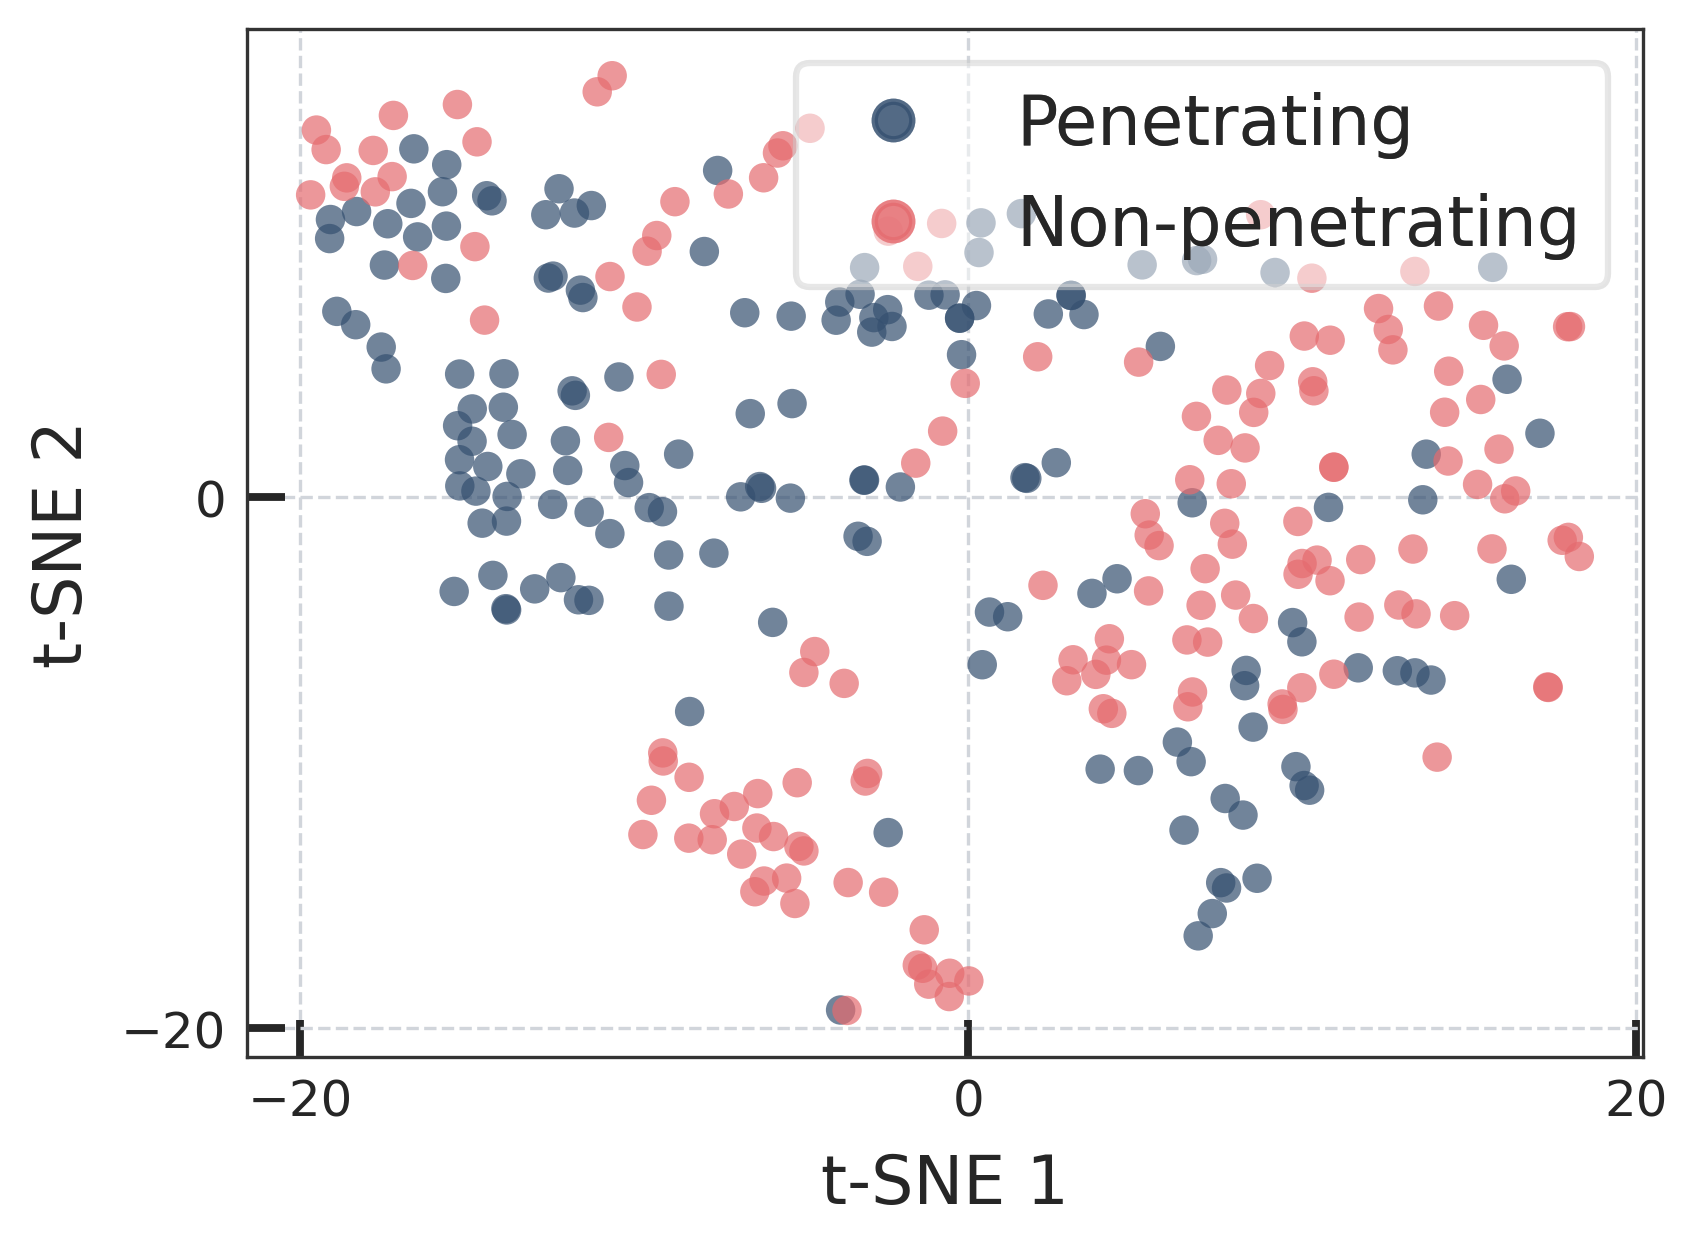

In [15]:
# # import CellPPD data
# df_CellPPD = pd.read_csv('../data/CellPPD_test.csv')

# # generate embeddings for CellPPD data
# embeddings_CellPPD = generate_embeddings(model, tokenizer, df_CellPPD['smiles'].tolist())
# embeddings_CellPPD_2d = reduce_embeddings_tsne(embeddings_CellPPD)
# df_CellPPD['t-SNE1'] = embeddings_CellPPD_2d[:, 0]
# df_CellPPD['t-SNE2'] = embeddings_CellPPD_2d[:, 1]

# # drop smiles column
# df_CellPPD = df_CellPPD.drop(columns=['smiles'])

# # save the dataframe with t-SNE, remove embeddings to save space
# df_CellPPD.to_csv('figure_data/fig4C_CellPPD_embeddings.csv', index=False)

# load the dataframe with t-SNE
df_CellPPD = pd.read_csv('figure_data/fig4C_CellPPD_embeddings.csv')

# generate the plot
generate_plot(df_CellPPD, 'label', s=50, alpha=0.7, cmap=custom_cmap, legend_names=["Non-penetrating", "Penetrating"])# cmap="vlag_r", figname="figures/fig4C_CellPPD_tsne.svg")
# generate_plot(df_CellPPD, 'label', s=50, alpha=0.7, cmap=custom_cmap, legend_names=["Non-penetrating", "Penetrating"])#cmap="vlag_r", figname="figures/fig4C_CellPPD_tsne.pdf")


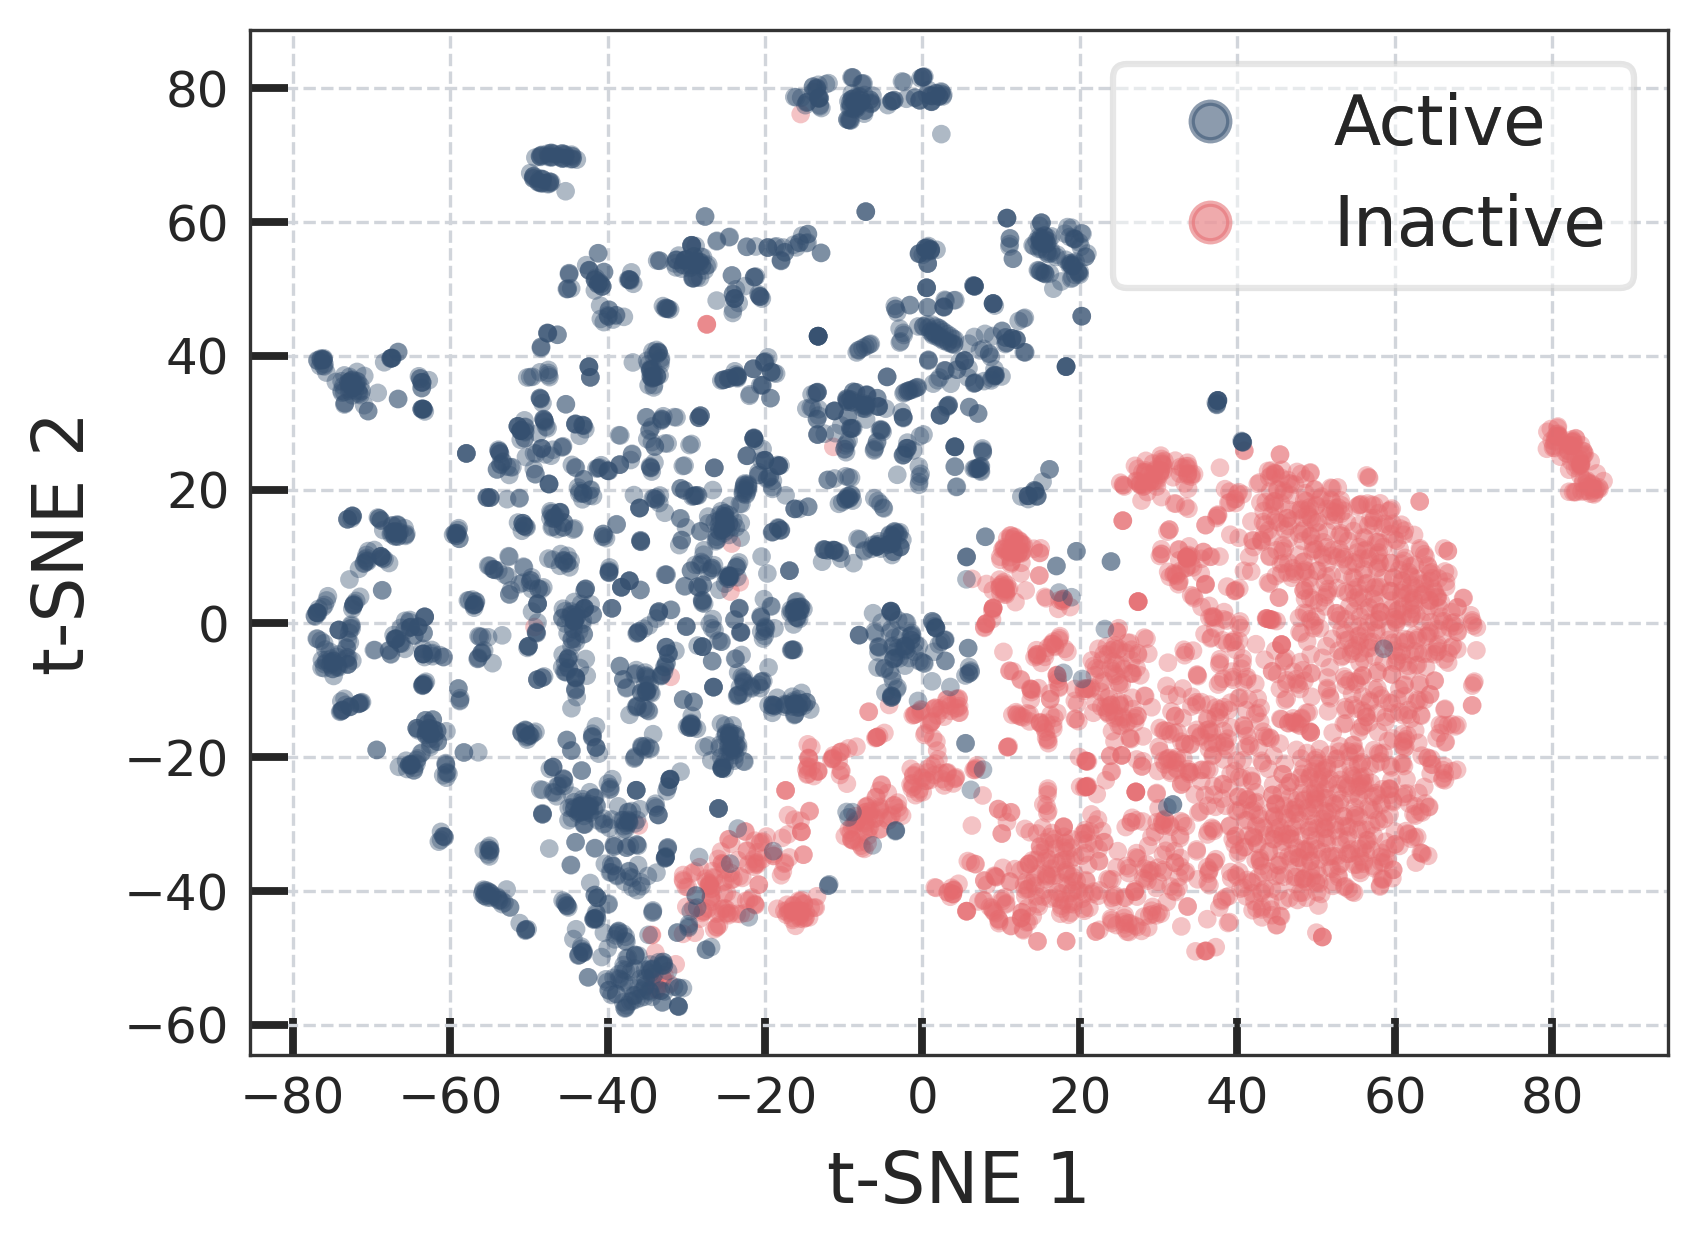

In [27]:
# # import AmpHGT data
# df_AmpHGT = pd.read_csv('../data/amp_test.csv')

# # generate embeddings for AmpHGT data
# embeddings_AmpHGT = generate_embeddings(model, tokenizer, df_AmpHGT['smiles'].tolist())
# embeddings_AmpHGT_2d = reduce_embeddings_tsne(embeddings_AmpHGT)
# df_AmpHGT['t-SNE1'] = embeddings_AmpHGT_2d[:, 0]
# df_AmpHGT['t-SNE2'] = embeddings_AmpHGT_2d[:, 1]

# # remove smiles column to save space
# df_AmpHGT = df_AmpHGT.drop(columns=['smiles'])

# # save the dataframe with t-SNE, remove embeddings to save space
# df_AmpHGT.to_csv('figure_data/fig4E_AmpHGT_embeddings.csv', index=False)

# load the dataframe with t-SNE
df_AmpHGT = pd.read_csv('figure_data/fig4E_AmpHGT_embeddings.csv')

# generate the plot
generate_plot(df_AmpHGT, 'label', s=20, alpha=0.4, cmap=custom_cmap, legend_names=["Inactive", "Active"])# cmap="vlag_r", figname="figures/fig4E_AmpHGT_tsne.svg")
# generate_plot(df_AmpHGT, 'label', s=20, alpha=0.3, cmap=custom_cmap, legend_names=["Non-penetrating", "Penetrating"])#cmap="vlag_r", figname="figures/fig4E_AmpHGT_tsne.pdf")


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import matthews_corrcoef


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


def resolve_existing_path(relative_candidates):
    for rel in relative_candidates:
        candidate = repo_root / rel
        if candidate.exists():
            return candidate
    tried = [str(repo_root / rel) for rel in relative_candidates]
    raise ValueError(f"None of the expected sources exist: {tried}")


repo_root = find_repo_root(Path.cwd())
print(f"Repo root: {repo_root}")

MODEL_NAME_MAP = {
    "aaronfeller_peptideclm-2-mlm-large": "aaronfeller_PeptideMLM_lg",
    "aaronfeller_peptideclm-2-hybrid-large": "aaronfeller_PeptideMLM-MTR_lg",
    "aaronfeller_peptideclm-2-mtr-large": "aaronfeller_PeptideMTR_lg",
}

RUN_GROUPS = {
    "PeptideCLM-2 + KAN": [
        {
            "run": "kan_base",
            "path": resolve_existing_path([
                "results_lg_models/BERT+KAN_predictions_all_models.csv",
            ]),
        },
        {"run": "kan_rerun2", "path": repo_root / "results_Pepmsnd_kan_models2"},
        {"run": "kan_rerun3", "path": repo_root / "results_Pepmsnd_kan_models3"},
    ],
    "PeptideCLM-2": [
        {
            "run": "bert_base",
            "path": resolve_existing_path([
                "results_pepmsnd_justBERTlg/BERT-ONLY_predictions_all_models.csv",
            ]),
        },
        {"run": "bert_rerun2", "path": repo_root / "results_pepmsnd_just_BERT2"},
        {"run": "bert_rerun3", "path": repo_root / "results_pepmsnd_just_BERT3-redo"},
    ],
}

for group_name, run_specs in RUN_GROUPS.items():
    print(f"\n{group_name}")
    for spec in run_specs:
        print(f"  {spec['run']}: {spec['path'].exists()} -> {spec['path']}")

In [ ]:
from pathlib import Path

def find_best_mcc_threshold(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_true_bin = (y_true >= 0.5).astype(int)

    unique_thresholds = np.unique(y_prob)
    if unique_thresholds.size == 0:
        return 0.5, float("nan")

    candidates = np.concatenate([
        [np.nextafter(unique_thresholds[0], -np.inf)],
        unique_thresholds,
        [np.nextafter(unique_thresholds[-1], np.inf)],
    ])

    best_t = float(candidates[0])
    best_mcc = -np.inf

    for threshold in candidates:
        y_pred = (y_prob >= threshold).astype(int)
        mcc = matthews_corrcoef(y_true_bin, y_pred)
        if np.isnan(mcc):
            mcc = -1.0

        if (mcc > best_mcc + 1e-12) or (
            abs(mcc - best_mcc) <= 1e-12 and abs(threshold - 0.5) < abs(best_t - 0.5)
        ):
            best_mcc = float(mcc)
            best_t = float(threshold)

    return best_t, best_mcc


def load_experiment_predictions(source_path: Path, group_name: str, run_name: str):
    if source_path.is_file():
        df = pd.read_csv(source_path).copy()
        if {"true_label", "predicted_prob"} <= set(df.columns):
            df = df.rename(columns={"true_label": "true", "predicted_prob": "predicted"})

        required = {"molecule", "true", "predicted"}
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"Missing required columns for {group_name}/{run_name}: {missing}")

        if "model" not in df.columns:
            df["model"] = "__single__"

        df["run"] = run_name
        return df[["molecule", "true", "predicted", "model", "run"]].copy()

    if source_path.is_dir():
        pred_paths = sorted(source_path.glob("*/fold*/preds_fold*.csv"))
        if not pred_paths:
            raise ValueError(f"No per-fold prediction files found for {group_name}/{run_name}: {source_path}")

        rows = []
        for pred_path in pred_paths:
            fold_name = pred_path.parent.name
            if not fold_name.startswith("fold"):
                continue
            try:
                fold_id = int(fold_name.replace("fold", ""))
            except ValueError:
                continue

            model_dir = pred_path.parent.parent.name
            canonical_model = MODEL_NAME_MAP.get(model_dir, model_dir)

            fold_df = pd.read_csv(pred_path).copy()
            if {"true_label", "predicted_prob"} <= set(fold_df.columns):
                fold_df = fold_df.rename(columns={
                    "true_label": "true",
                    "predicted_prob": "predicted",
                })

            required = {"true", "predicted"}
            missing = required - set(fold_df.columns)
            if missing:
                raise ValueError(f"Missing required columns in {pred_path}: {missing}")

            fold_df["model"] = canonical_model
            fold_df["run"] = run_name
            fold_df["molecule"] = [f"{run_name}_fold{fold_id}_idx{i}" for i in range(len(fold_df))]
            rows.append(fold_df[["molecule", "true", "predicted", "model", "run"]])

        if not rows:
            raise ValueError(f"No usable fold predictions parsed for {group_name}/{run_name}: {source_path}")

        return pd.concat(rows, ignore_index=True)

    raise ValueError(f"Experiment source does not exist for {group_name}/{run_name}: {source_path}")


def score_group(group_name: str, run_specs):
    frames = []
    for spec in run_specs:
        frames.append(load_experiment_predictions(spec["path"], group_name, spec["run"]))

    df = pd.concat(frames, ignore_index=True)
    if df.empty:
        raise ValueError(f"No rows loaded for group: {group_name}")

    # Extract the fold number from the generated molecule string
    fold_series = df["molecule"].astype(str).str.extract(r"fold(\d+)_")[0]
    df = df.loc[fold_series.notna()].copy()
    if df.empty:
        raise ValueError(
            f"No fold IDs parsed for {group_name}; expected molecule format including fold<id>_."
        )
    df["fold"] = fold_series[fold_series.notna()].astype(int).to_numpy()

    # Drop predicted_label if it exists in any of the underlying files
    if "predicted_label" in df.columns:
        df = df.drop(columns=["predicted_label"])

    model_summary_rows = []
    fold_rows = []
    run_rows = []

    # 1. Process all metrics across models, runs, and folds (Per-Fold Optimization)
    for model, g_model in sorted(df.groupby("model")):
        run_mean_mccs = []
        run_mean_thresholds = []

        for run_name, g_run in sorted(g_model.groupby("run")):
            run_fold_mccs = []
            run_fold_thresholds = []

            for fold_id, g_fold in sorted(g_run.groupby("fold")):
                # Back to per-fold threshold optimization
                best_t, fold_mcc = find_best_mcc_threshold(
                    g_fold["true"].to_numpy(), g_fold["predicted"].to_numpy()
                )
                run_fold_mccs.append(fold_mcc)
                run_fold_thresholds.append(best_t)
                
                fold_rows.append(
                    {
                        "group": group_name,
                        "model": model,
                        "run": run_name,
                        "fold": int(fold_id),
                        "mcc": float(fold_mcc),
                        "threshold": float(best_t),
                        "n": int(len(g_fold)),
                    }
                )

            finite_run_fold_mccs = np.asarray([x for x in run_fold_mccs if np.isfinite(x)], dtype=float)
            if finite_run_fold_mccs.size == 0:
                continue

            run_mean_mcc = float(np.mean(finite_run_fold_mccs))
            run_mean_threshold = float(np.mean(run_fold_thresholds))
            run_mean_mccs.append(run_mean_mcc)
            run_mean_thresholds.append(run_mean_threshold)
            run_rows.append(
                {
                    "group": group_name,
                    "model": model,
                    "run": run_name,
                    "mean_mcc": run_mean_mcc,
                    "mean_threshold": run_mean_threshold,
                    "n_folds": int(finite_run_fold_mccs.size),
                }
            )

        finite_run_means = np.asarray([x for x in run_mean_mccs if np.isfinite(x)], dtype=float)
        if finite_run_means.size == 0:
            continue

        mean_mcc = float(np.mean(finite_run_means))
        std_mcc = float(np.std(finite_run_means, ddof=1)) if finite_run_means.size > 1 else 0.0
        se_mcc = float(std_mcc / np.sqrt(finite_run_means.size)) if finite_run_means.size > 0 else np.nan
        ci95_mcc = float(1.96 * se_mcc) if np.isfinite(se_mcc) else np.nan

        model_summary_rows.append(
            {
                "group": group_name,
                "model": model,
                "mean_mcc": mean_mcc,
                "std_mcc": std_mcc,
                "se_mcc": se_mcc,
                "ci95_mcc": ci95_mcc,
                "mean_threshold": float(np.mean(run_mean_thresholds)),
                "n_runs": int(finite_run_means.size),
            }
        )

    if not fold_rows:
        raise ValueError(f"No model/fold rows generated for {group_name}.")

    model_summary_df = pd.DataFrame(model_summary_rows)
    model_fold_df = pd.DataFrame(fold_rows).sort_values(["group", "model", "run", "fold"])
    model_run_df = pd.DataFrame(run_rows).sort_values(["group", "model", "run"])

    # 2. Save the consolidated raw prediction file per unique run (18 total files)
    final_pred_cols = ["molecule", "fold", "true", "predicted", "model", "run"]
    existing_pred_cols = [c for c in final_pred_cols if c in df.columns]
    
    for run_name, g_run_preds in df.groupby("run"):
        matching_spec = next((s for s in run_specs if s["run"] == run_name), None)
        if matching_spec:
            base_path = Path(matching_spec["path"])
            output_dir = base_path if base_path.is_dir() else base_path.parent
            
            output_file = output_dir / f"{run_name}_all_predictions.csv"
            clean_export_df = g_run_preds[existing_pred_cols].sort_values(["model", "fold"])
            clean_export_df.to_csv(output_file, index=False)
            print(f"Saved aggregated predictions to: {output_file}")

    return model_summary_df, model_fold_df, model_run_df

In [ ]:
summary_frames = []
model_fold_frames = []
model_run_frames = []

for group_name, run_specs in RUN_GROUPS.items():
    summary_df, model_fold_df, model_run_df = score_group(group_name, run_specs)
    summary_frames.append(summary_df)
    model_fold_frames.append(model_fold_df)
    model_run_frames.append(model_run_df)

all_summary = pd.concat(summary_frames, ignore_index=True)
all_model_folds = pd.concat(model_fold_frames, ignore_index=True)
all_model_runs = pd.concat(model_run_frames, ignore_index=True)

all_summary_sorted = all_summary.sort_values(["group", "model"], ascending=[True, True])
display(all_summary_sorted.round(4))

output_csv = repo_root / "results_comparison_scores_by_model_mcc.csv"
all_summary_sorted.to_csv(output_csv, index=False)
print(f"Saved summary table to: {output_csv}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Global Plot Layout Configuration ---
BAR_ALLOCATION_WIDTH = 0.24  # Total space allocated for each bar's slot
VISUAL_BAR_SCALE = 0.85      # Scale factor (< 1.0 creates gaps between bars)

PLOT_COLORS = ["#E69F00", "#56B4E9", "#009E73"]
EDGE_COLORS = ["#CC7A00", "#4280B3", "#007A66"]
BASELINE_COLOR = "#808080"
BASELINE_LABEL = "PepMSND"
BASELINE_VALUES = {
    "PeptideCLM-2 + KAN": 0.726,
    "PeptideCLM-2": 0.537,
}

MODEL_LABELS = {
    "aaronfeller_PeptideMLM_lg": "MLM",
    "aaronfeller_PeptideMLM-MTR_lg": "Hybrid",
    "aaronfeller_PeptideMTR_lg": "MTR",
}

MODEL_ORDER = [
    "aaronfeller_PeptideMLM_lg",
    "aaronfeller_PeptideMLM-MTR_lg",
    "aaronfeller_PeptideMTR_lg",
]

GROUP_ORDER = ["PeptideCLM-2 + KAN", "PeptideCLM-2"]

def plot_grouped_mcc(summary_df, err_col, output_name):
    fig, ax = plt.subplots(figsize=(5.0, 3.0), dpi=300)
    x_positions = np.arange(len(GROUP_ORDER), dtype=float)

    total_bars = len(MODEL_ORDER)
    max_offset = BAR_ALLOCATION_WIDTH * (total_bars - 1) / 2
    offsets = np.linspace(-max_offset, max_offset, num=total_bars)

    for i, model_name in enumerate(MODEL_ORDER):
        color = PLOT_COLORS[i % len(PLOT_COLORS)]
        edgecolor = EDGE_COLORS[i % len(EDGE_COLORS)]
        label = MODEL_LABELS.get(model_name, model_name)

        heights = []
        errors = []
        for group_name in GROUP_ORDER:
            row = summary_df.loc[
                (summary_df["group"] == group_name) & (summary_df["model"] == model_name)
            ]
            if row.empty:
                heights.append(np.nan)
                errors.append(np.nan)
            else:
                heights.append(float(row.iloc[0]["mean_mcc"]))
                errors.append(float(row.iloc[0][err_col]))

        # current_x represents the true mathematical center of the bar
        current_x = x_positions + offsets[i]
        
        # Draw bars scaled down relative to their allocation slot
        ax.bar(
            current_x,
            heights,
            width=BAR_ALLOCATION_WIDTH * VISUAL_BAR_SCALE,
            color=color,
            edgecolor="black",
            alpha=0.9,
            label=label,
            zorder=2,
        )
        
        # Error bars stay locked to the absolute center coordinate
        ax.errorbar(
            current_x,
            heights,
            yerr=errors,
            fmt="none",
            ecolor="black",
            elinewidth=1.1,
            capsize=3,
            zorder=4,
        )

    for j, group_name in enumerate(GROUP_ORDER):
        base_val = BASELINE_VALUES.get(group_name)
        if base_val is None:
            continue

        # Added a multiplier to BAR_ALLOCATION_WIDTH to push the baseline ends wider
        xmin = x_positions[j] - max_offset - (BAR_ALLOCATION_WIDTH * 1.1)
        xmax = x_positions[j] + max_offset + (BAR_ALLOCATION_WIDTH * 1.1)
        baseline_label = BASELINE_LABEL if j == 0 else None
        
        ax.hlines(
            y=base_val,
            xmin=xmin,
            xmax=xmax,
            colors=BASELINE_COLOR,
            linestyles="dashed",
            linewidth=1.6,  # Slightly thicker line to balance the wider width
            label=baseline_label,
            zorder=1,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(GROUP_ORDER, rotation=0, ha="center")
    ax.set_ylabel("Mean MCC")
    ax.set_ylim(0.0, 1.0)
    ax.legend(title="", frameon=False, bbox_to_anchor=(0.73, 0.98), loc="upper left", fontsize=8)
    fig.tight_layout()

    output_path = repo_root / "main" / "results" / output_name
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved figure to: {output_path}")
    plt.show()

plot_grouped_mcc(
    all_summary_sorted,
    "ci95_mcc",
    "pepmsnd_compare_grouped_by_model_mcc_ci95.png",
)

In [ ]:
# import glob
# import numpy as np
# import pandas as pd
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE

# # Configuration
# EMBED_MODEL = "aaronfeller/PeptideMLM_lg"
# BATCH_SIZE = 64
# MAX_LENGTH = 2046
# MAX_POINTS = 2500
# SEED = 7

# rng = np.random.default_rng(SEED)

# def load_data():
#     pep_dir = repo_root / "main" / "data" / "PepMSND_data"
#     test_paths = sorted(glob.glob(str(pep_dir / "X_test*.csv")))
    
#     if not test_paths:
#         raise FileNotFoundError(f"No files found in: {pep_dir}")

#     df = pd.concat((pd.read_csv(p) for p in test_paths), ignore_index=True)
#     df = df.drop_duplicates(subset=["ID"]).reset_index(drop=True)

#     if len(df) > MAX_POINTS:
#         keep_idx = rng.choice(len(df), size=MAX_POINTS, replace=False)
#         df = df.iloc[np.sort(keep_idx)].reset_index(drop=True)
        
#     return df

# def get_backbone_embeddings(smiles):
#     import torch
#     from transformers import AutoTokenizer, AutoModel

#     device = "cuda" if torch.cuda.is_available() else "cpu"
#     if device == "cpu":
#         print("Warning: CUDA not available, stopping execution to avoid very slow processing on CPU.")
#         raise ValueError("CUDA not available")
#     print(f"Using device: {device}")
    
#     tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL, trust_remote_code=True)
#     backbone = AutoModel.from_pretrained(EMBED_MODEL, trust_remote_code=True).to(device).eval()

#     def mean_pool(last_hidden_state, attention_mask):
#         mask = attention_mask.to(last_hidden_state.dtype).unsqueeze(-1)
#         summed = (last_hidden_state * mask).sum(dim=1)
#         denom = mask.sum(dim=1).clamp(min=1e-6)
#         return summed / denom

#     all_emb = []
#     with torch.no_grad():
#         for i in range(0, len(smiles), BATCH_SIZE):
#             batch = smiles[i : i + BATCH_SIZE]
#             enc = tokenizer(batch, truncation=True, padding=True, max_length=MAX_LENGTH,
#                             add_special_tokens=True, return_tensors="pt")
            
#             input_ids = enc["input_ids"].to(device)
#             attention_mask = enc["attention_mask"].to(device)
#             outputs = backbone(input_ids=input_ids, attention_mask=attention_mask)
            
#             if isinstance(outputs, dict) and "mean_pool" in outputs:
#                 pooled = outputs["mean_pool"]
#             else:
#                 last_hidden = getattr(outputs, "last_hidden_state", outputs[0] if isinstance(outputs, (tuple, list)) else None)
#                 pooled = mean_pool(last_hidden, attention_mask)

#             pooled = torch.nan_to_num(pooled.detach().float(), nan=0.0, posinf=0.0, neginf=0.0)
#             all_emb.append(pooled.cpu())

#     emb = torch.cat(all_emb, dim=0).numpy().astype(np.float64)
#     finite_ratio = float(np.isfinite(emb).mean())
#     nonzero_ratio = float(np.mean(np.linalg.norm(np.nan_to_num(emb, nan=0.0), axis=1) > 1e-8))

#     if finite_ratio < 0.99 or nonzero_ratio < 0.5:
#         raise ValueError("Backbone embedding matrix is non-finite or mostly degenerate.")
        
#     return np.nan_to_num(emb, nan=0.0, posinf=0.0, neginf=0.0)

# def get_descriptor_embeddings(df):
#     meta_cols = {"ID", "PMID", "SMILES", "Length", "Species", "Environment", "SE-3", "label"}
#     desc_cols = [c for c in df.columns if c not in meta_cols and pd.to_numeric(df[c], errors="coerce").notna().mean() > 0.95]

#     if not desc_cols:
#         raise ValueError("Could not infer numeric descriptor columns.")

#     desc = df[desc_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float64)
#     desc = np.nan_to_num(desc, nan=0.0, posinf=0.0, neginf=0.0)

#     caps = np.nanpercentile(np.abs(desc), 99.5, axis=0)
#     caps = np.where((~np.isfinite(caps)) | (caps <= 0), 1.0, caps)
#     desc = np.clip(desc, -caps, caps)

#     mu = np.nanmean(desc, axis=0, keepdims=True)
#     sigma = np.where((s := np.nanstd(desc, axis=0, keepdims=True)) < 1e-8, 1.0, s)
    
#     emb = np.nan_to_num((desc - mu) / sigma, nan=0.0, posinf=0.0, neginf=0.0)
#     return emb, len(desc_cols)

# # Execute
# df = load_data()
# smiles = df["SMILES"].astype(str).tolist()

# try:
#     emb = get_backbone_embeddings(smiles)
#     embedding_source = "Backbone pooled embedding"
# except Exception as e:
#     print(f"[WARN] Backbone embedding unavailable: {type(e).__name__}: {e}")
#     emb, n_features = get_descriptor_embeddings(df)
#     embedding_source = f"Descriptor embedding ({n_features} features)"

# # Final normalization
# emb = np.nan_to_num(emb, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float64)
# norms = np.where((n := np.linalg.norm(emb, axis=1, keepdims=True)) < 1e-12, 1.0, n)
# emb = emb / norms

# # save the embeddings
# np.save("plotting_embeddings.npy", emb)


In [ ]:
# # load embeddings
# emb = np.load("plotting_embeddings.npy")

# def reduce_dimensions(emb):
#     # perplexity = int(np.clip(emb.shape[0] // 40, 5, 40))
#     perplexity = 15
#     reducer = TSNE(n_components=2, perplexity=perplexity, learning_rate="auto", init="pca", random_state=SEED)
#     return reducer.fit_transform(emb), "t-SNE"

# emb_2d, proj_name = reduce_dimensions(emb)

# plot_df = pd.DataFrame({
#     "x": emb_2d[:, 0],
#     "y": emb_2d[:, 1],
#     "label": df["label"].astype(int).to_numpy(),
#     "length": pd.to_numeric(df["Length"], errors="coerce").fillna(0).to_numpy(),
#     "species": df["Species"].astype(str).to_numpy(),
#     "environment": df["Environment"].astype(str).to_numpy(),
# })

# print(f"Loaded samples: {len(df)}")
# print(f"Embedding matrix: {emb.shape} | source: {embedding_source}")

# # save plot_df and metadata for potential future use
# output_dir = repo_root / "main" / "results" / "pepmsnd_embedding"
# output_dir.mkdir(parents=True, exist_ok=True)
# plot_df.to_csv(output_dir / "embedding_2d_projection.csv", index=False)
# print(f"Saved 2D embedding projection and metadata to: {output_dir / 'embedding_2d_projection.csv'}")


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# load the 2D projection and metadata if needed
# plot_df = pd.read_csv(repo_root / "main" / "results" / "pepmsnd_embedding" / "embedding_2d_projection.csv")
plot_df = pd.read_csv(repo_root / "main" / "results" / "pepmsnd_embedding" / "embedding_2d_projection.csv")

# make single plot 
fig, axes = plt.subplots(1, 1, figsize=(4, 3), dpi=150)

# Panel A: Class Label
palette = {0: "#355070", 1: "#E56B6F"}
for cls in sorted(plot_df["label"].unique()):
    g = plot_df[plot_df["label"] == cls]
    plt.scatter(
        g["x"], g["y"], s=22, alpha=0.62,
        c=palette.get(int(cls), "#666666"),
        edgecolors="none", label=f"label={int(cls)}"
    )

# plt.title(f"{proj_name} ({embedding_source}) by label")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
# plt.grid(alpha=0.2, linestyle="--")
# change label to "Stable (0) vs Unstable (1)"
plt.legend(["Stable", "Unstable"], frameon=True, loc="upper right")


# fig.suptitle("PepMSND Pre-Finetuning Embedding Landscape", y=1.02, fontsize=12)
fig.tight_layout()
plt.savefig(repo_root / "main" / "results" / "pepmsnd_embedding" / "embedding_2d_projection.svg", bbox_inches="tight", )
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import plotnine as p9

# Define the custom color palette
COLOR_PALETTE = {
    'True': "#A25C29",
    'False': "#2E6F9A"
}

FILL_PALETTE = {
    'True': "#DBA782", 
    'False': "#83BADE"
}

# --- 1. Data Loading and Transformation (Standard Python) ---

# data is proprietary and not able to be released
results_df = pd.read_csv('figure_data/fig5C_combined_fibrillation_results.csv') 

# data is proprietary and not able to be released
mfp = pd.read_csv('figure_data/fig5C_mfp_fibrillation.csv')
mfp['source_file'] = 'Morgan FP'
mfp['predicted_value'] = mfp['prediction']
results_df = pd.concat([results_df, mfp], ignore_index=True)

# Process source_file column to extract model size/name
results_df['source_file'] = results_df['source_file'].apply(lambda x: x.split('/')[0].split('_')[-1])
results_df['source_file'] = results_df['source_file'].str.replace('fibrillation', 'Large model')
results_df['source_file'] = results_df['source_file'].str.replace('medium', 'Base model')
results_df['source_file'] = results_df['source_file'].replace('Morgan fp', 'Morgan FP')
results_df['source_file'] = results_df['source_file'].str.replace('small', 'Small model')


# Sort source_file by small, base, large
model_size_order = ['Morgan FP', 'Small model', 'Base model', 'Large model']
results_df['source_file'] = pd.Categorical(results_df['source_file'], categories=model_size_order, ordered=True)

# Identify the prediction column and apply Sigmoid
if 'mean_prediction' in results_df.columns:
    results_df['predicted_value'] = results_df['mean_prediction']
elif 'prediction' in results_df.columns:
    results_df['predicted_value'] = results_df['prediction']
else:
    raise KeyError("Missing required prediction column.")

results_df['predicted_value'] = 1 / (1 + np.exp(-results_df['predicted_value']))

# --- 2. Prepare Data for Plotting ---
plotting_df = results_df.copy()
# Note: 'value' (0/1) will be used for AUROC calculation
plotting_df['Fibril Forming'] = plotting_df['value'].apply(lambda x: 'False' if x < 0.5 else 'True')


# --- 3. Calculate AUROC for Annotation ---
auroc_data = []
for model_size in model_size_order:
    subset = results_df[results_df['source_file'] == model_size]
    
    if not subset.empty and len(subset['value'].unique()) > 1:
        # Calculate AUROC using true binary labels and predicted probabilities
        auroc = roc_auc_score(subset['value'], subset['predicted_value'])
        auroc_label = "\n\n" + f"AUROC: {auroc:.3f}"
    else:
        auroc_label = "N/A"
        
    auroc_data.append({
        'Model Size': model_size, 
        'AUROC_Label': auroc_label
    })

# Create a separate DataFrame for annotations
auroc_df = pd.DataFrame(auroc_data)
auroc_df['source_file'] = pd.Categorical(auroc_df['Model Size'], categories=model_size_order, ordered=True)

# --- 4. Plotting with plotnine ---
p = (
    # REMOVED y='predicted_value' from aes(). geom_density calculates its own Y.
    p9.ggplot(plotting_df, p9.aes(x='predicted_value', fill='Fibril Forming', color='Fibril Forming'))
    
    # 1. Add Density Geometry
    # Added alpha=0.5 so you can see the overlap between True/False
    + p9.geom_density(alpha=0.5)

    # 2. Facet by Model Size
    # CORRECTED: Changed 'source_file' to 'Model Size' (matches your rename in Step 2)
    + p9.facet_grid(
        'source_file',
        scales='free'
        )

    
    # 3. Add AUROC Text (Fixed for Faceting)
    # We map 'Model Size' to group so the facet knows where to put the label
    + p9.geom_text(
        # set y to a ratio of max y value for better placement
        # p9.aes(x=[0.5, 0.7, 0.5, 0.5], y=[5, 2.2, 2.4, 2.5], label='AUROC_Label', group='source_file'),
        p9.aes(x=[0.7, 0.7, 0.7, 0.7], y=np.inf, label='AUROC_Label', group='source_file'),
        data=auroc_df,
        va='top',
        inherit_aes=False,
        size=10,
    )

    # 4. Custom Colors
    + p9.scale_fill_manual(values=FILL_PALETTE)
    + p9.scale_color_manual(values=COLOR_PALETTE)
    
    # 5. Scales
    # X-axis is the Probability (0 to 1)
    + p9.scale_x_continuous(name="Model prediction", limits=(0, 1), 
                            # make 0.00 into 0 and 1.00 into 1
                            breaks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
                            labels=['0', '0.2', '0.4', '0.6', '0.8', '1'],
                            expand=(0,0)
                           )
    
    + p9.scale_y_continuous(name="Density",
                            expand=(0,0,0.1,0)
                           )
    
    # 6. Labels and Theme
    + p9.labs(fill="Fibril Forming")
    # + p9.theme_classic()
    + p9.theme(
        # add top and right splines
        plot_title=p9.element_text(hjust=0.5, size=14, weight='bold'),
        legend_position='right',
        axis_title_y=p9.element_text(size=12),
        axis_title_x=p9.element_text(size=13, color="black"),
        legend_title=p9.element_text(text='Aggregation\n', size=11),
        # font size for facet labels
        strip_text=p9.element_text(size=13),
        # remove y axis text
        axis_text_y=p9.element_text(size=8),
        # remove all gridlines
        panel_grid_major=p9.element_blank(),
        panel_grid_minor=p9.element_blank(),
        # remove padding around facets
        panel_spacing=p9.element_text(size=0),
        # put facet titles in box
        strip_background=p9.element_rect(fill="#FFFFFF", color="#000000"),
        # remove y axis ticks
        axis_ticks_y=p9.element_blank(),
        # put each facet in its own box
        panel_border=p9.element_rect(color="#000000", fill=None, size=1),
        # plot background to white
        panel_background=p9.element_rect(fill="#FFFFFF"),

        # set figure size
        figure_size=(8, 6),
        
    )
    # + p9.coord_cartesian(expand=False)
)

# --- 5. Save Plot ---
p.save("figures/fig5C_fibrillation_density.svg", width=8, height=6, dpi=300)
p.save("figures/fig5C_fibrillation_density.pdf", width=8, height=6, dpi=300)


/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/fig5C_fibrillation_density.svg
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/fig5C_fibrillation_density.pdf


In [24]:
# generate embeddings from df["embedding_0"] to df["embedding_1023"] columns
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# Data is proprietary and not able to be released
df = pd.read_csv('figure_data/fig5AB_tsne_label.csv')

def create_cmap(name='BuOr', N=256, c1 ="#4992c9", c2="#c97c40"):
    # 1. Define the RGB color stops
    colors = [
        c1, c2
        # # "#3995db", #4482b3, # Blue
        # "#e38842", #b57a4c # Orange
        # "#e38842" #b57a4c # Orange
        ]
    cmap = LinearSegmentedColormap.from_list(name, colors, N=N)
    mpl.colormaps.register(cmap=cmap, name=name, force=True)    
    return cmap

# 1. Run the function to define and register the colormap:
create_cmap('Or', N=256, c1 ="#c97c40", c2="#c97c40")
create_cmap('Bu', N=256, c1 ="#4992c9", c2="#4992c9")

# plot each class separately
for class_value in df['value'].unique():
    df_subset = df[df['value'] == class_value]
    if class_value == 0:
        generate_plot(df_subset, 'value', s=20, alpha=0.2, cmap="Bu", figname=f"figures/fig5A_false_values.svg")
        generate_plot(df_subset, 'value', s=20, alpha=0.2, cmap="Bu", figname=f"figures/fig5A_false_values.pdf")
    else:
        generate_plot(df_subset, 'value', s=20, alpha=0.5, cmap="Or", figname=f"figures/fig5B_true_values.svg")
        generate_plot(df_subset, 'value', s=20, alpha=0.5, cmap="Or", figname=f"figures/fig5B_true_values.pdf")

/tmp/ipykernel_1605612/73235157.py:20: UserWarning: Overwriting the cmap 'Or' that was already in the registry.
/tmp/ipykernel_1605612/73235157.py:20: UserWarning: Overwriting the cmap 'Bu' that was already in the registry.
